In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import os
import time
from sklearn.preprocessing import OneHotEncoder
from google.colab import drive

# Load Google Drive
drive.mount('/content/drive')

# 定義檔案路徑
train_file_path = '/content/drive/My Drive/Disc_Training_Validation.xlsx'
test_file_path = '/content/drive/My Drive/Disc_Test.xlsx'

# Load data
df_train = pd.read_excel(train_file_path)
df_test = pd.read_excel(test_file_path)


# Check whether required columns exist
required_columns = ['MRN', 'Level']
for col in required_columns:
    if col not in df_train.columns:
        raise ValueError(f"Training file 缺少必要欄位: {col}")
    if col not in df_test.columns:
        raise ValueError(f"Test file 缺少必要欄位: {col}")

# Display basic information
print("=== Training Data Info ===")
print(f"Training shape: {df_train.shape}")
print(f"Training unique patients (MRN): {df_train['MRN'].nunique()}")

print("\n=== Test Data Info ===")
print(f"Test shape: {df_test.shape}")
print(f"Test unique patients (MRN): {df_test['MRN'].nunique()}")

# Check for patient overlap between train/test
train_mrn = set(df_train['MRN'].astype(str))
test_mrn = set(df_test['MRN'].astype(str))
overlap_mrn = train_mrn.intersection(test_mrn)

print("\n=== Patient Overlap Check ===")
print(f"Number of overlapping MRNs between train and test: {len(overlap_mrn)}")
if len(overlap_mrn) > 0:
    print("Warning: train/test 存在病人重疊，這不符合 patient-level split！")
    print("部分重疊 MRN:", list(overlap_mrn)[:10])
else:
    print("No overlapping MRNs found. Patient-level separation looks correct.")

# Check number of images per patient
print("\n=== Training images per patient ===")
print(df_train.groupby('MRN').size().describe())

print("\n=== Test images per patient ===")
print(df_test.groupby('MRN').size().describe())

# Step 2: One-Hot encode the Level column
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

level_encoded_train = encoder.fit_transform(df_train[['Level']])
level_columns = encoder.get_feature_names_out(['Level'])
df_train[level_columns] = level_encoded_train

level_encoded_test = encoder.transform(df_test[['Level']])
df_test[level_columns] = level_encoded_test

# Inspect data
print("\n=== Training Data Columns ===")
print(df_train.columns.tolist())

print("\n=== Test Data Columns ===")
print(df_test.columns.tolist())

print("\n=== Training Data Sample ===")
print(df_train.head())

print("\n=== Test Data Sample ===")
print(df_test.head())

Mounted at /content/drive
=== Training Data Info ===
Training shape: (605, 10)
Training unique patients (MRN): 121

=== Test Data Info ===
Test shape: (120, 10)
Test unique patients (MRN): 40

=== Patient Overlap Check ===
Number of overlapping MRNs between train and test: 0
No overlapping MRNs found. Patient-level separation looks correct.

=== Training images per patient ===
count    121.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
dtype: float64

=== Test images per patient ===
count    40.0
mean      3.0
std       0.0
min       3.0
25%       3.0
50%       3.0
75%       3.0
max       3.0
dtype: float64

=== Training Data Columns ===
['Disc_AP', 'Disc_Width', 'Disc_Area', 'Percentage', 'Depth', 'Incision', 'Kambin_Base', 'Cord_Width', 'MRN', 'Level', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== Test Data Columns ===
['Disc_AP', 'Disc_Width', 'Disc_Area', 'Percentage', 'Depth', 'Incision', 'Kambin_

# **Data Inspection**

In [ ]:
# Check the number of images per MRN
mrn_counts = df_train.groupby('MRN').size().reset_index(name='image_count')

print("=== MRN image count summary ===")
print(mrn_counts['image_count'].describe())

print("\n=== Distribution of image counts per MRN ===")
print(mrn_counts['image_count'].value_counts().sort_index())

=== MRN image count summary ===
count    121.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: image_count, dtype: float64

=== Distribution of image counts per MRN ===
image_count
5    121
Name: count, dtype: int64


In [ ]:
# Identify patients with image count not equal to 5
abnormal_mrn_counts = mrn_counts[mrn_counts['image_count'] != 5].copy()

print("=== MRNs with image count != 5 ===")
print(abnormal_mrn_counts.sort_values('image_count', ascending=False))

print(f"\nNumber of abnormal MRNs: {len(abnormal_mrn_counts)}")

=== MRNs with image count != 5 ===
Empty DataFrame
Columns: [MRN, image_count]
Index: []

Number of abnormal MRNs: 0


# **Correlation Analysis**

Correlation with Incision (raw features only):
Incision       1.000000
Kambin_Base    0.661719
Depth          0.445168
Disc_Width     0.261255
Cord_Width     0.217618
Disc_AP       -0.071433
Name: Incision, dtype: float64

Correlation between Disc_AP and Disc_Width: 0.799400


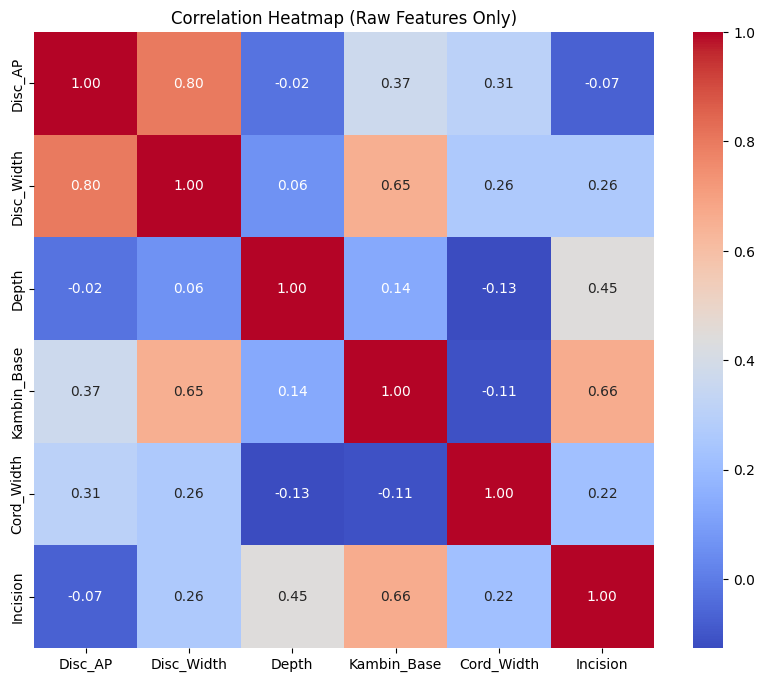

In [ ]:
# ============================
# Part 1: Basic exploration + definition of raw features
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Raw numerical features (excluding target column, Level text column, and MRN)
raw_numeric_features = [
    'Disc_AP',
    'Disc_Width',
    'Depth',
    'Kambin_Base',
    'Cord_Width'
]

target_column = 'Incision'
level_feature_columns = list(level_columns)

# 1. Examine correlation between raw features and target (exploratory only, not used for formal feature selection)
correlation = df_train[raw_numeric_features + [target_column]].corr()[target_column].sort_values(ascending=False)
print("Correlation with Incision (raw features only):")
print(correlation)

# 2. Examine correlation between Disc_AP and Disc_Width
correlation_disc_ap_width = df_train[['Disc_AP', 'Disc_Width']].corr().iloc[0, 1]
print(f"\nCorrelation between Disc_AP and Disc_Width: {correlation_disc_ap_width:.6f}")

# 3. Visualize correlation among raw features
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[raw_numeric_features + [target_column]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Raw Features Only)')
plt.show()

# **Model Comparison**

In [ ]:
# ============================
# Model comparison with updated dataset
# Patient-level internal split + independent external test
# ============================

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------
# Step 1: basic settings
# ----------------------------
target_column = 'Incision'
raw_numeric_features = ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']
level_feature_columns = list(level_columns)

# patient-level split within development set
groups = df_train['MRN'].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_train, groups=groups))

df_internal_train = df_train.iloc[train_idx].copy()
df_internal_val = df_train.iloc[val_idx].copy()

print("=== Internal Split Check ===")
print(f"Internal training images: {len(df_internal_train)}")
print(f"Internal validation images: {len(df_internal_val)}")
print(f"Internal training patients: {df_internal_train['MRN'].nunique()}")
print(f"Internal validation patients: {df_internal_val['MRN'].nunique()}")

overlap_internal = set(df_internal_train['MRN']).intersection(set(df_internal_val['MRN']))
print(f"Overlapping MRNs between internal train and val: {len(overlap_internal)}")

print("\n=== External Test Check ===")
print(f"External test images: {len(df_test)}")
print(f"External test patients: {df_test['MRN'].nunique()}")

overlap_external = set(df_train['MRN']).intersection(set(df_test['MRN']))
print(f"Overlapping MRNs between development set and external test: {len(overlap_external)}")

# ----------------------------
# Step 2: preprocessing
# PCA fit only on internal training
# ----------------------------
scaler_pca = StandardScaler()

X_internal_train_raw = scaler_pca.fit_transform(df_internal_train[raw_numeric_features])
X_internal_val_raw = scaler_pca.transform(df_internal_val[raw_numeric_features])
X_external_test_raw = scaler_pca.transform(df_test[raw_numeric_features])

pca = PCA(n_components=0.90)
X_internal_train_pca = pca.fit_transform(X_internal_train_raw)
X_internal_val_pca = pca.transform(X_internal_val_raw)
X_external_test_pca = pca.transform(X_external_test_raw)

pca_features = [f'PCA{i+1}' for i in range(pca.n_components_)]

print("\n=== PCA Info ===")
print("Number of components selected:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

# merge PCA + one-hot level
df_internal_train_pca = pd.DataFrame(X_internal_train_pca, columns=pca_features, index=df_internal_train.index)
df_internal_val_pca = pd.DataFrame(X_internal_val_pca, columns=pca_features, index=df_internal_val.index)
df_external_test_pca = pd.DataFrame(X_external_test_pca, columns=pca_features, index=df_test.index)

X_internal_train_df = pd.concat([df_internal_train_pca, df_internal_train[level_feature_columns]], axis=1)
X_internal_val_df = pd.concat([df_internal_val_pca, df_internal_val[level_feature_columns]], axis=1)
X_external_test_df = pd.concat([df_external_test_pca, df_test[level_feature_columns]], axis=1)

selected_features = list(X_internal_train_df.columns)
print("\nSelected features:", selected_features)

y_internal_train = df_internal_train[target_column].values
y_internal_val = df_internal_val[target_column].values
y_external_test = df_test[target_column].values

# ----------------------------
# Step 3: scaler for models
# ----------------------------
scaler_model = StandardScaler()

X_internal_train = scaler_model.fit_transform(X_internal_train_df)
X_internal_val = scaler_model.transform(X_internal_val_df)
X_external_test = scaler_model.transform(X_external_test_df)

print("\n=== Final Input Shapes ===")
print("X_internal_train:", X_internal_train.shape)
print("X_internal_val:", X_internal_val.shape)
print("X_external_test:", X_external_test.shape)

# ----------------------------
# Step 4: helper functions
# ----------------------------
def evaluate_model(name, model, X_tr, y_tr, X_val, y_val, X_test, y_test):
    model.fit(X_tr, y_tr)

    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    result = {
        "Model": name,
        "Internal_MSE": mean_squared_error(y_val, y_val_pred),
        "Internal_MAE": mean_absolute_error(y_val, y_val_pred),
        "Internal_R2": r2_score(y_val, y_val_pred),
        "External_MSE": mean_squared_error(y_test, y_test_pred),
        "External_MAE": mean_absolute_error(y_test, y_test_pred),
        "External_R2": r2_score(y_test, y_test_pred),
    }
    return result

def build_ann(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='mean_squared_error',
        metrics=['mean_squared_error']
    )
    return model

# ----------------------------
# Step 5: classical ML models
# ----------------------------
results = []

# Linear Regression
lr_model = LinearRegression()
results.append(
    evaluate_model(
        "Linear Regression",
        lr_model,
        X_internal_train, y_internal_train,
        X_internal_val, y_internal_val,
        X_external_test, y_external_test
    )
)

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_internal_train, y_internal_train,
        X_internal_val, y_internal_val,
        X_external_test, y_external_test
    )
)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
results.append(
    evaluate_model(
        "Gradient Boosting",
        gb_model,
        X_internal_train, y_internal_train,
        X_internal_val, y_internal_val,
        X_external_test, y_external_test
    )
)

# ElasticNet
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000)
results.append(
    evaluate_model(
        "ElasticNet",
        en_model,
        X_internal_train, y_internal_train,
        X_internal_val, y_internal_val,
        X_external_test, y_external_test
    )
)

# ----------------------------
# Step 6: ANN
# ----------------------------
tf.random.set_seed(42)
np.random.seed(42)

ann_model = build_ann(X_internal_train.shape[1])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

history = ann_model.fit(
    X_internal_train, y_internal_train,
    validation_data=(X_internal_val, y_internal_val),
    epochs=500,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=0
)

y_val_pred_ann = ann_model.predict(X_internal_val).flatten()
y_test_pred_ann = ann_model.predict(X_external_test).flatten()

results.append({
    "Model": "ANN",
    "Internal_MSE": mean_squared_error(y_internal_val, y_val_pred_ann),
    "Internal_MAE": mean_absolute_error(y_internal_val, y_val_pred_ann),
    "Internal_R2": r2_score(y_internal_val, y_val_pred_ann),
    "External_MSE": mean_squared_error(y_external_test, y_test_pred_ann),
    "External_MAE": mean_absolute_error(y_external_test, y_test_pred_ann),
    "External_R2": r2_score(y_external_test, y_test_pred_ann),
})

# ----------------------------
# Step 7: summary table
# ----------------------------
results_df = pd.DataFrame(results)

print("\n=== Model Comparison: Internal Validation ===")
print(
    results_df[["Model", "Internal_MSE", "Internal_MAE", "Internal_R2"]]
    .sort_values(by="Internal_R2", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Model Comparison: External Validation ===")
print(
    results_df[["Model", "External_MSE", "External_MAE", "External_R2"]]
    .sort_values(by="External_R2", ascending=False)
    .reset_index(drop=True)
)

# Figure 11
figure11_df = (
    results_df[["Model", "External_MSE", "External_MAE", "External_R2"]]
    .rename(columns={
        "External_MSE": "MSE",
        "External_MAE": "MAE",
        "External_R2": "R²"
    })
    .sort_values(by="R²", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Figure 11 Table (External Validation) ===")
print(figure11_df)

# Save as Excel
output_path = "/content/drive/My Drive/model_comparison_updated.xlsx"
with pd.ExcelWriter(output_path) as writer:
    results_df.to_excel(writer, sheet_name="All_Results", index=False)
    figure11_df.to_excel(writer, sheet_name="Figure11_External", index=False)

print(f"\nSaved to: {output_path}")

=== Internal Split Check ===
Internal training images: 480
Internal validation images: 125
Internal training patients: 96
Internal validation patients: 25
Overlapping MRNs between internal train and val: 0

=== External Test Check ===
External test images: 120
External test patients: 40
Overlapping MRNs between development set and external test: 0

=== PCA Info ===
Number of components selected: 4
Explained variance ratio: [0.46458665 0.25196213 0.16757632 0.09341645]
Total explained variance: 0.9775415441874797

Selected features: ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== Final Input Shapes ===
X_internal_train: (480, 9)
X_internal_val: (125, 9)
X_external_test: (120, 9)
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

=== Model Comparison: Internal Validation ===
               Model  Internal_MSE  Internal_MAE  Internal_R2
0                ANN     28.108983      3.910894     0.946152
1  Linear 

# **Final Incision Model**

=== Internal Split Check ===
Internal training images: 480
Internal validation images: 125
Internal training patients: 96
Internal validation patients: 25
Overlapping MRNs between internal train and val: 0

=== External Test Check ===
External test images: 120
External test patients: 40
Overlapping MRNs between development set and external test: 0

=== PCA Info ===
Number of components selected: 4
Explained variance ratio: [0.44929901 0.26319353 0.16823216 0.09487376]
Total explained variance: 0.9755984689638545

Selected features for ANN: ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== Final Model Input Shapes ===
X_internal_train: (480, 9)
X_internal_val: (125, 9)
X_external_test: (120, 9)

=== Training run 1/10 (seed=0) ===
Run seed=0: val R²=0.9285, val MAE=3.8660

=== Training run 2/10 (seed=1) ===
Run seed=1: val R²=0.9350, val MAE=3.7617

=== Training run 3/10 (seed=2) ===


Run seed=2: val R²=0.9327, val MAE=3.7660

=== Training run 4/10 (seed=3) ===
Run seed=3: val R²=0.9292, val MAE=3.7756

=== Training run 5/10 (seed=4) ===
Run seed=4: val R²=0.9302, val MAE=3.8121

=== Training run 6/10 (seed=5) ===
Run seed=5: val R²=0.9287, val MAE=3.8530

=== Training run 7/10 (seed=6) ===
Run seed=6: val R²=0.9341, val MAE=3.6355

=== Training run 8/10 (seed=7) ===
Run seed=7: val R²=0.9306, val MAE=3.7892

=== Training run 9/10 (seed=8) ===
Run seed=8: val R²=0.9312, val MAE=3.8033

=== Training run 10/10 (seed=9) ===
Run seed=9: val R²=0.9291, val MAE=3.8738

=== Best model selected ===
Best seed: 1
Best internal val R²: 0.9350
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Internal Validation Performance ===
MSE: 23.8746
MAE: 3.7617
R² : 0.9350
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

=== External Validation Performance ===
MSE: 64.4128
MAE: 6.0787
R² : 0.9178

=== External Validation 95% CI (bootstrap) ===
MSE 95% CI: [45.26198181 91.53251975]
MAE 95% CI: [5.1687994

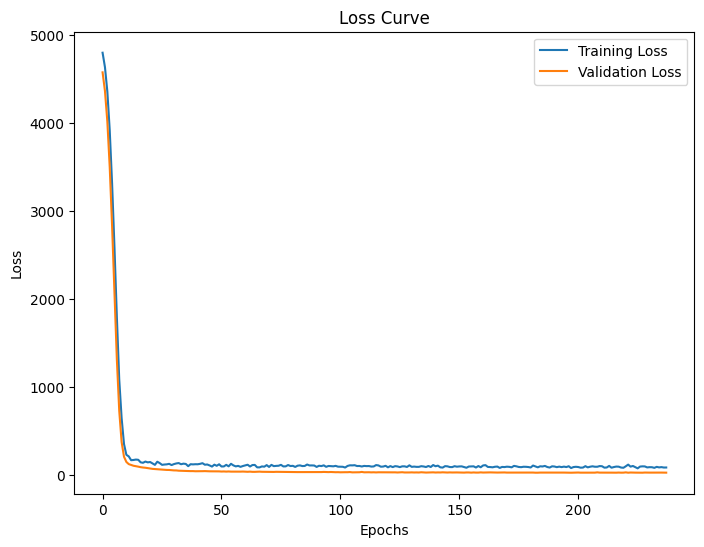

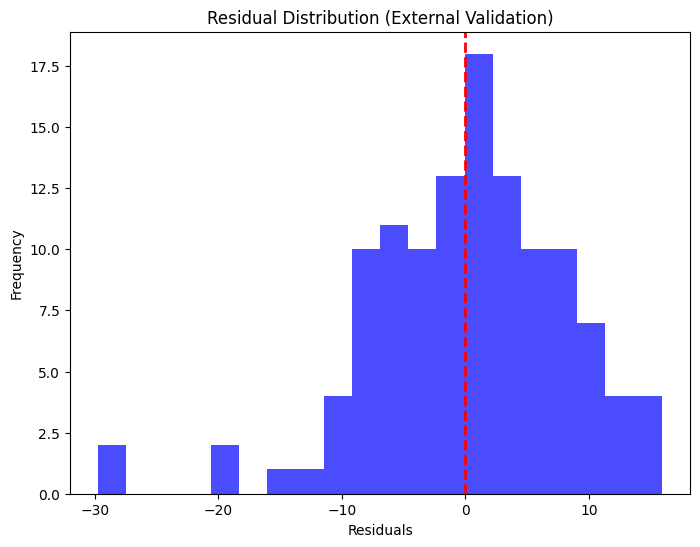

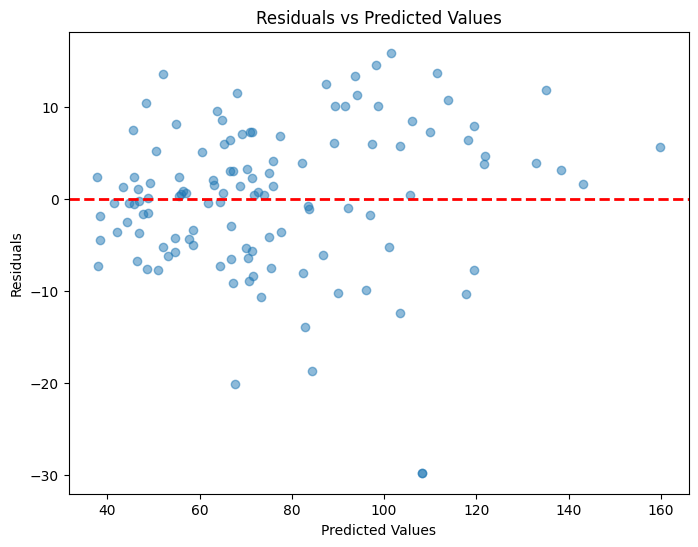

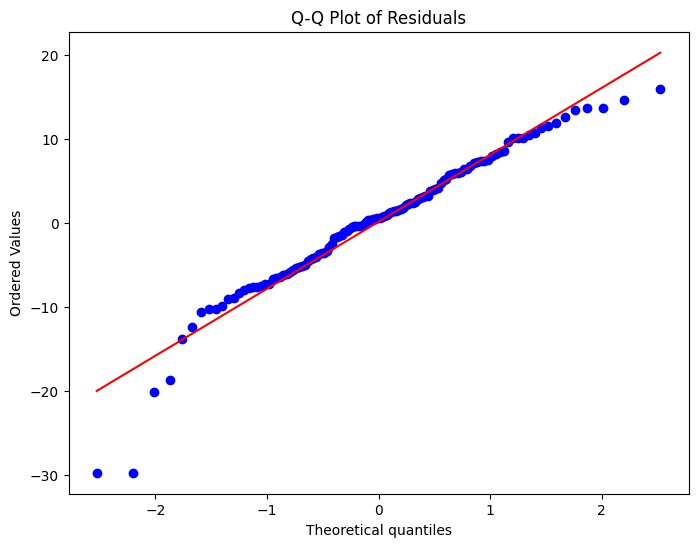


Shapiro-Wilk test for residuals: p-value = 0.0005
Residuals are not normally distributed (p <= 0.05).
Skewness of residuals: -0.8418


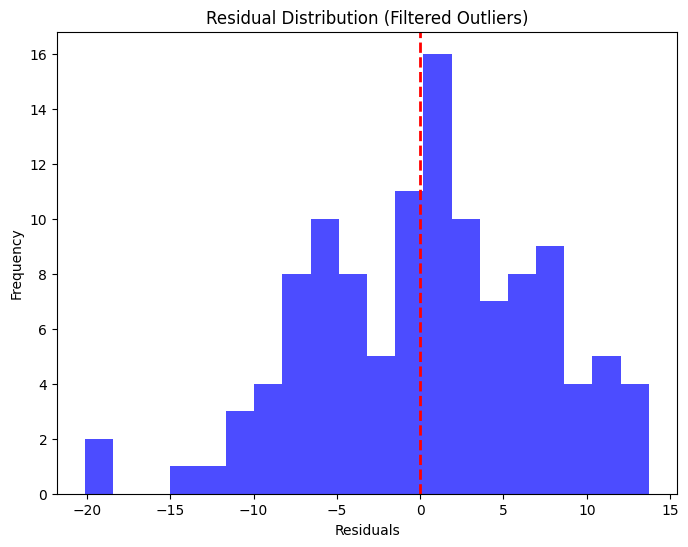

Shapiro-Wilk test for filtered residuals: p-value = 0.3071
Filtered residuals are normally distributed (p > 0.05).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
模型儲存成功: /content/drive/My Drive/saved_models_2026/incision_model/incision_model.keras
Preprocessing bundle 儲存成功: /content/drive/My Drive/saved_models_2026/incision_model/preprocessing_bundle.pkl
檔案 incision_model.keras 存在且非空白，大小: 40438 bytes
檔案 preprocessing_bundle.pkl 存在且非空白，大小: 2769 bytes
Incision 模型與 preprocessing bundle 已成功儲存至: /content/drive/My Drive/saved_models_2026/incision_model/


In [ ]:
# ============================
# Part 2: Patient-level internal validation + external test
# ============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, skew

# ----------------------------
# Step 1: Data preparation
# ----------------------------
target_column = 'Incision'
raw_numeric_features = ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']
level_feature_columns = list(level_columns)

# groups = MRN, used later for internal validation splitting
groups = df_train['MRN'].copy()

# Perform internal train/validation split within df_train using patient-level split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(df_train, groups=groups))

df_internal_train = df_train.iloc[train_idx].copy()
df_internal_val = df_train.iloc[val_idx].copy()

print("=== Internal Split Check ===")
print(f"Internal training images: {len(df_internal_train)}")
print(f"Internal validation images: {len(df_internal_val)}")
print(f"Internal training patients: {df_internal_train['MRN'].nunique()}")
print(f"Internal validation patients: {df_internal_val['MRN'].nunique()}")

overlap_internal = set(df_internal_train['MRN']).intersection(set(df_internal_val['MRN']))
print(f"Overlapping MRNs between internal train and val: {len(overlap_internal)}")

print("\n=== External Test Check ===")
print(f"External test images: {len(df_test)}")
print(f"External test patients: {df_test['MRN'].nunique()}")

overlap_external = set(df_train['MRN']).intersection(set(df_test['MRN']))
print(f"Overlapping MRNs between development set and external test: {len(overlap_external)}")

# ----------------------------
# Step 2: PCA (fit only on internal training set)
# ----------------------------
scaler_pca = StandardScaler()

X_internal_train_raw = scaler_pca.fit_transform(df_internal_train[raw_numeric_features])
X_internal_val_raw = scaler_pca.transform(df_internal_val[raw_numeric_features])
X_external_test_raw = scaler_pca.transform(df_test[raw_numeric_features])

pca = PCA(n_components=0.90)
X_internal_train_pca = pca.fit_transform(X_internal_train_raw)
X_internal_val_pca = pca.transform(X_internal_val_raw)
X_external_test_pca = pca.transform(X_external_test_raw)

print("\n=== PCA Info ===")
print("Number of components selected:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

pca_features = [f'PCA{i+1}' for i in range(pca.n_components_)]

# Convert PCA results to DataFrame for easier merging
df_internal_train_pca = pd.DataFrame(X_internal_train_pca, columns=pca_features, index=df_internal_train.index)
df_internal_val_pca = pd.DataFrame(X_internal_val_pca, columns=pca_features, index=df_internal_val.index)
df_external_test_pca = pd.DataFrame(X_external_test_pca, columns=pca_features, index=df_test.index)

# Add Level one-hot encoded features
X_internal_train_df = pd.concat([df_internal_train_pca, df_internal_train[level_feature_columns]], axis=1)
X_internal_val_df = pd.concat([df_internal_val_pca, df_internal_val[level_feature_columns]], axis=1)
X_external_test_df = pd.concat([df_external_test_pca, df_test[level_feature_columns]], axis=1)

selected_features = list(X_internal_train_df.columns)
print("\nSelected features for ANN:", selected_features)

y_internal_train = df_internal_train[target_column].values
y_internal_val = df_internal_val[target_column].values
y_external_test = df_test[target_column].values

# ----------------------------
# Step 3: Apply scaler again before ANN (final model input)
# ----------------------------
scaler_ann = StandardScaler()

X_internal_train = scaler_ann.fit_transform(X_internal_train_df)
X_internal_val = scaler_ann.transform(X_internal_val_df)
X_external_test = scaler_ann.transform(X_external_test_df)

print("\n=== Final Model Input Shapes ===")
print("X_internal_train:", X_internal_train.shape)
print("X_internal_val:", X_internal_val.shape)
print("X_external_test:", X_external_test.shape)

# ----------------------------
# Step 4: Define ANN
# ----------------------------
import random
import os
import copy

def set_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_improved_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.1),
        Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='mean_squared_error',
        metrics=['mean_squared_error']
    )
    return model

n_runs = 10
best_val_r2 = -np.inf
best_model = None
best_history = None
best_seed = None

for seed in range(n_runs):
    print(f"\n=== Training run {seed+1}/{n_runs} (seed={seed}) ===")

    set_all_seeds(seed)

    current_model = build_improved_model(X_internal_train.shape[1])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=40,
        restore_best_weights=True
    )

    current_history = current_model.fit(
        X_internal_train, y_internal_train,
        validation_data=(X_internal_val, y_internal_val),
        epochs=500,
        batch_size=8,
        callbacks=[early_stopping],
        verbose=0
    )

    current_val_pred = current_model.predict(X_internal_val, verbose=0).flatten()
    current_val_r2 = r2_score(y_internal_val, current_val_pred)
    current_val_mae = mean_absolute_error(y_internal_val, current_val_pred)

    print(f"Run seed={seed}: val R²={current_val_r2:.4f}, val MAE={current_val_mae:.4f}")

    if current_val_r2 > best_val_r2:
        best_val_r2 = current_val_r2
        best_model = current_model
        best_history = current_history
        best_seed = seed

print("\n=== Best model selected ===")
print(f"Best seed: {best_seed}")
print(f"Best internal val R²: {best_val_r2:.4f}")

improved_model = best_model
history = best_history

# ----------------------------
# Step 5: internal validation
# ----------------------------
y_val_pred = improved_model.predict(X_internal_val).flatten()

val_mse = mean_squared_error(y_internal_val, y_val_pred)
val_mae = mean_absolute_error(y_internal_val, y_val_pred)
val_r2 = r2_score(y_internal_val, y_val_pred)

print("\n=== Internal Validation Performance ===")
print(f"MSE: {val_mse:.4f}")
print(f"MAE: {val_mae:.4f}")
print(f"R² : {val_r2:.4f}")

# ----------------------------
# Step 6: external validation
# ----------------------------
y_test_pred = improved_model.predict(X_external_test).flatten()

test_mse = mean_squared_error(y_external_test, y_test_pred)
test_mae = mean_absolute_error(y_external_test, y_test_pred)
test_r2 = r2_score(y_external_test, y_test_pred)

print("\n=== External Validation Performance ===")
print(f"MSE: {test_mse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² : {test_r2:.4f}")

# ----------------------------
# Step 7:  bootstrap 95% CI（external test）
# ----------------------------
n_boot = 1000
rng = np.random.default_rng(42)

mse_list = []
mae_list = []
r2_list = []

for _ in range(n_boot):
    idx = rng.integers(0, len(y_external_test), len(y_external_test))
    y_true_b = y_external_test[idx]
    y_pred_b = y_test_pred[idx]

    mse_list.append(mean_squared_error(y_true_b, y_pred_b))
    mae_list.append(mean_absolute_error(y_true_b, y_pred_b))
    r2_list.append(r2_score(y_true_b, y_pred_b))

def ci95(x):
    return np.percentile(x, [2.5, 97.5])

print("\n=== External Validation 95% CI (bootstrap) ===")
print(f"MSE 95% CI: {ci95(mse_list)}")
print(f"MAE 95% CI: {ci95(mae_list)}")
print(f"R²  95% CI: {ci95(r2_list)}")

# ----------------------------
# Step 8: Feature importance
# ----------------------------
weights = improved_model.get_weights()[0]
importance = np.abs(weights).mean(axis=1)
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importance (weight-based, exploratory only) ===")
print(importance_df)

# ----------------------------
# Step 9: Noise robustness test
# ----------------------------
X_test_noisy = X_external_test + np.random.normal(0, 0.1, X_external_test.shape)
y_test_pred_noisy = improved_model.predict(X_test_noisy).flatten()

print("\n=== Noisy External Test Performance ===")
print(f"MSE: {mean_squared_error(y_external_test, y_test_pred_noisy):.4f}")
print(f"MAE: {mean_absolute_error(y_external_test, y_test_pred_noisy):.4f}")
print(f"R² : {r2_score(y_external_test, y_test_pred_noisy):.4f}")

# ----------------------------
# Step 10: Visualization
# ----------------------------

# 損失曲線
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

# External residuals
residuals = y_external_test - y_test_pred

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, color='blue', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2)
plt.title("Residual Distribution (External Validation)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='dashed', linewidth=2)
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro-Wilk
stat, p = shapiro(residuals)
print(f"\nShapiro-Wilk test for residuals: p-value = {p:.4f}")
if p > 0.05:
    print("Residuals are normally distributed (p > 0.05).")
else:
    print("Residuals are not normally distributed (p <= 0.05).")

# Skewness
skewness = skew(residuals)
print(f"Skewness of residuals: {skewness:.4f}")

# Filter residuals at 1% / 99%
lower_bound = np.percentile(residuals, 1)
upper_bound = np.percentile(residuals, 99)
residuals_filtered = residuals[(residuals >= lower_bound) & (residuals <= upper_bound)]

plt.figure(figsize=(8, 6))
plt.hist(residuals_filtered, bins=20, color='blue', alpha=0.7)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2)
plt.title("Residual Distribution (Filtered Outliers)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

stat, p = shapiro(residuals_filtered)
print(f"Shapiro-Wilk test for filtered residuals: p-value = {p:.4f}")
if p > 0.05:
    print("Filtered residuals are normally distributed (p > 0.05).")
else:
    print("Filtered residuals are not normally distributed (p <= 0.05).")

# ============================
# Step 11: Save best model and preprocessing bundle
# ============================

import pickle
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

save_dir = '/content/drive/My Drive/saved_models_2026/incision_model/'
os.makedirs(save_dir, exist_ok=True)

required_objects = {
    "model": improved_model,
    "encoder": encoder,
    "scaler_pca": scaler_pca,
    "pca": pca,
    "scaler_ann": scaler_ann,
    "raw_numeric_features": raw_numeric_features,
    "level_feature_columns": level_feature_columns,
    "selected_features": selected_features,
    "target_column": target_column
}

for name, obj in required_objects.items():
    if obj is None:
        raise ValueError(f"Object {name} has not been properly initialized")

improved_model.save(os.path.join(save_dir, 'incision_model.keras'))
print("Model successfully saved:", os.path.join(save_dir, 'incision_model.keras'))

preprocessing_bundle = {
    "encoder": encoder,
    "scaler_pca": scaler_pca,
    "pca": pca,
    "scaler_ann": scaler_ann,
    "raw_numeric_features": raw_numeric_features,
    "level_feature_columns": level_feature_columns,
    "selected_features": selected_features,
    "target_column": target_column,
    "best_seed": best_seed,
    "best_val_r2": best_val_r2
}

with open(os.path.join(save_dir, 'preprocessing_bundle.pkl'), 'wb') as f:
    pickle.dump(preprocessing_bundle, f)

print("Preprocessing bundle successfully saved:", os.path.join(save_dir, 'preprocessing_bundle.pkl'))

for file_name in ['incision_model.keras', 'preprocessing_bundle.pkl']:
    file_path = os.path.join(save_dir, file_name)
    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
        print(f"檔案 {file_name} exists and is not empty, size: {os.path.getsize(file_path)} bytes")
    else:
        raise ValueError(f"File {file_name} failed to save or is empty")

print("Incision model and preprocessing bundle have been successfully saved to:", save_dir)

# **For future Colab sessions: directly load the model without retraining**

In [ ]:
# ============================
# Step 12: Load saved model and preprocessing bundle
# ============================

import pickle
import tensorflow as tf
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

save_dir = '/content/drive/My Drive/saved_models_2026/incision_model/'

with open(os.path.join(save_dir, 'preprocessing_bundle.pkl'), 'rb') as f:
    loaded_bundle = pickle.load(f)

loaded_model = tf.keras.models.load_model(
    os.path.join(save_dir, 'incision_model.keras')
)

loaded_encoder = loaded_bundle["encoder"]
loaded_scaler_pca = loaded_bundle["scaler_pca"]
loaded_pca = loaded_bundle["pca"]
loaded_scaler_ann = loaded_bundle["scaler_ann"]
loaded_raw_numeric_features = loaded_bundle["raw_numeric_features"]
loaded_level_feature_columns = loaded_bundle["level_feature_columns"]
loaded_selected_features = loaded_bundle["selected_features"]

print("Model and preprocessing bundle loaded successfully")
print("best_seed:", loaded_bundle.get("best_seed", None))
print("best_val_r2:", loaded_bundle.get("best_val_r2", None))
print("loaded_selected_features:", loaded_selected_features)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
模型與 preprocessing bundle 載入成功
best_seed: 1
best_val_r2: 0.9349865142967213
loaded_selected_features: ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']


# **Load External test**

In [ ]:
# ============================
# Step 13: Rebuild external test features and predict
# ============================

import pandas as pd
import numpy as np

# 1. Extract raw numeric features from the external test set
X_test_raw = df_test[loaded_raw_numeric_features].copy()

# 2. Standardize before PCA
X_test_raw_scaled = loaded_scaler_pca.transform(X_test_raw)

# 3. Apply PCA transformation
X_test_pca = loaded_pca.transform(X_test_raw_scaled)

pca_features = [f'PCA{i+1}' for i in range(X_test_pca.shape[1])]
df_test_pca = pd.DataFrame(X_test_pca, columns=pca_features, index=df_test.index)

# 4. Merge with level one-hot encoded features
X_test_df = pd.concat([df_test_pca, df_test[loaded_level_feature_columns]], axis=1)

# 5. Ensure column order matches the training phase
X_test_df = X_test_df[loaded_selected_features]

# 6. Standardize before ANN input
X_external_test_loaded = loaded_scaler_ann.transform(X_test_df)

# 7. Prediction
y_true = df_test["Incision"].values
y_pred = loaded_model.predict(X_external_test_loaded).flatten()

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("Prediction done.")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
y_true shape: (120,)
y_pred shape: (120,)
Prediction done.


# **測試**

In [ ]:
# ============================
# Step 13: Debug the same pipeline as Hugging Face
# ============================

def debug_app_pipeline_in_colab(
    level,
    disc_ap,
    disc_width,
    cord_width,
    kambin_base,
    depth,
    model,
    encoder,
    scaler_pca,
    pca,
    scaler_ann,
    raw_numeric_features,
    level_feature_columns,
    selected_features,
):
    # Ensure consistency with the HF app
    cord_width = cord_width / 2

    input_df = pd.DataFrame(
        [{
            "Disc_AP": disc_ap,
            "Disc_Width": disc_width,
            "Depth": depth,
            "Kambin_Base": kambin_base,
            "Cord_Width": cord_width,
            "Level": level,
        }],
        index=[0]
    )

    print("=== input_df ===")
    print(input_df)

    X_raw = input_df[raw_numeric_features]
    print("\n=== X_raw ===")
    print(X_raw)
    print("X_raw columns:", list(X_raw.columns))

    X_raw_scaled = scaler_pca.transform(X_raw)
    print("\n=== X_raw_scaled ===")
    print(X_raw_scaled)

    X_pca = pca.transform(X_raw_scaled)
    pca_features = [f"PCA{i+1}" for i in range(X_pca.shape[1])]
    df_pca = pd.DataFrame(X_pca, columns=pca_features, index=[0])
    print("\n=== df_pca ===")
    print(df_pca)
    print("df_pca columns:", list(df_pca.columns))

    level_encoded = encoder.transform(input_df[["Level"]])
    if hasattr(level_encoded, "toarray"):
        level_encoded = level_encoded.toarray()

    df_level = pd.DataFrame(level_encoded, columns=level_feature_columns, index=[0])
    print("\n=== df_level ===")
    print(df_level)
    print("df_level columns:", list(df_level.columns))

    X_final_df = pd.concat([df_pca, df_level], axis=1)

    for col in selected_features:
        if col not in X_final_df.columns:
            X_final_df[col] = 0

    X_final_df = X_final_df[selected_features]

    print("\n=== selected_features ===")
    print(selected_features)

    print("\n=== X_final_df ===")
    print(X_final_df)
    print("X_final_df columns:", list(X_final_df.columns))

    X_final = scaler_ann.transform(X_final_df)
    print("\n=== X_final ===")
    print(X_final)
    print("X_final shape:", X_final.shape)

    pred = model.predict(X_final, verbose=0).flatten()[0]
    print("\n=== prediction ===")
    print(pred)

    return {
        "input_df": input_df,
        "X_raw": X_raw,
        "X_raw_scaled": X_raw_scaled,
        "X_pca": X_pca,
        "df_pca": df_pca,
        "df_level": df_level,
        "X_final_df": X_final_df,
        "X_final": X_final,
        "prediction": pred,
    }

# **Debugging using the same HF test sample**

In [ ]:
result_incision = debug_app_pipeline_in_colab(
    level="L34",
    disc_ap=47.096377,
    disc_width=61.800006,
    cord_width=23.15607,
    kambin_base=10.204207,
    depth=56.6,
    model=loaded_model,
    encoder=loaded_encoder,
    scaler_pca=loaded_scaler_pca,
    pca=loaded_pca,
    scaler_ann=loaded_scaler_ann,
    raw_numeric_features=loaded_raw_numeric_features,
    level_feature_columns=loaded_level_feature_columns,
    selected_features=loaded_selected_features,
)

=== input_df ===
     Disc_AP  Disc_Width  Depth  Kambin_Base  Cord_Width Level
0  47.096377   61.800006   56.6    10.204207   11.578035   L34

=== X_raw ===
     Disc_AP  Disc_Width  Depth  Kambin_Base  Cord_Width
0  47.096377   61.800006   56.6    10.204207   11.578035
X_raw columns: ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']

=== X_raw_scaled ===
[[ 1.65926793  1.20034318 -0.82812353 -0.68437969  0.52693691]]

=== df_pca ===
       PCA1      PCA2      PCA3      PCA4
0  1.444951  1.457711 -0.217718 -1.134859
df_pca columns: ['PCA1', 'PCA2', 'PCA3', 'PCA4']

=== df_level ===
   Level_L12  Level_L23  Level_L34  Level_L45  Level_L5S1
0        0.0        0.0        1.0        0.0         0.0
df_level columns: ['Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== selected_features ===
['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== X_final_df ===
       PCA1      PCA2      PCA3      PCA4  Level_

# **ICC**

In [ ]:
# ============================
# ICC calculation (patient-level clustering)
# ============================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Use the training set for ICC calculation (development dataset)
df_icc = df_train.copy()

# Ensure MRN is treated as a string
df_icc["MRN"] = df_icc["MRN"].astype(str)

print("Total images:", len(df_icc))
print("Total patients:", df_icc["MRN"].nunique())

# mixed-effects model
model = smf.mixedlm("Incision ~ 1", df_icc, groups=df_icc["MRN"])
result = model.fit()

print(result.summary())

# variance components
var_patient = result.cov_re.iloc[0, 0]
var_residual = result.scale

print("\nVariance components:")
print("Patient variance:", var_patient)
print("Residual variance:", var_residual)

# ICC
icc = var_patient / (var_patient + var_residual)

print("\nICC:", icc)

# design effect
m = df_icc.groupby("MRN").size().mean()

design_effect = 1 + (m - 1) * icc

print("Mean images per patient:", m)
print("Design effect:", design_effect)

# effective sample size
n_total = len(df_icc)
n_effective = n_total / design_effect

print("Total N:", n_total)
print("Effective N:", n_effective)

Total images: 605
Total patients: 121


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Incision  
No. Observations: 605     Method:             REML      
No. Groups:       121     Scale:              410.8309  
Min. group size:  5       Log-Likelihood:     -2687.7564
Max. group size:  5       Converged:          No        
Mean group size:  5.0                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     66.885    0.896 74.661 0.000 65.129 68.641
Group Var     14.941    0.727                           


Variance components:
Patient variance: 14.940564791187509
Residual variance: 410.8309147642359

ICC: 0.03509057207586557
Mean images per patient: 5.0
Design effect: 1.1403622883034623
Total N: 605
Effective N: 530.5331526703409


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 4.636215
  warnings.warn(msg, ConvergenceWarning)


# **GroupKFold**

In [ ]:
# ============================
# GroupKFold cross-validation (patient-level)
# ============================

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
import numpy as np

raw_numeric_features = ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']
level_feature_columns = list(level_columns)
target_column = 'Incision'

groups = df_train["MRN"].astype(str)

gkf = GroupKFold(n_splits=5)

mse_list = []
mae_list = []
r2_list = []

fold = 1

for train_idx, val_idx in gkf.split(df_train, groups=groups):

    print(f"\n===== Fold {fold} =====")

    df_tr = df_train.iloc[train_idx].copy()
    df_val = df_train.iloc[val_idx].copy()

    print("Train patients:", df_tr["MRN"].nunique())
    print("Val patients:", df_val["MRN"].nunique())

    # ----------------------
    # PCA (fit only on train)
    # ----------------------

    scaler_pca = StandardScaler()

    X_tr_raw = scaler_pca.fit_transform(df_tr[raw_numeric_features])
    X_val_raw = scaler_pca.transform(df_val[raw_numeric_features])

    pca = PCA(n_components=0.9)

    X_tr_pca = pca.fit_transform(X_tr_raw)
    X_val_pca = pca.transform(X_val_raw)

    pca_features = [f"PCA{i+1}" for i in range(pca.n_components_)]

    df_tr_pca = pd.DataFrame(X_tr_pca, columns=pca_features, index=df_tr.index)
    df_val_pca = pd.DataFrame(X_val_pca, columns=pca_features, index=df_val.index)

    X_tr_df = pd.concat([df_tr_pca, df_tr[level_feature_columns]], axis=1)
    X_val_df = pd.concat([df_val_pca, df_val[level_feature_columns]], axis=1)

    y_tr = df_tr[target_column].values
    y_val = df_val[target_column].values

    # ----------------------
    # scaler for ANN
    # ----------------------

    scaler_ann = StandardScaler()

    X_tr = scaler_ann.fit_transform(X_tr_df)
    X_val = scaler_ann.transform(X_val_df)

    # ----------------------
    # ANN
    # ----------------------

    tf.random.set_seed(42)
    np.random.seed(42)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_tr.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mse"
    )

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=40,
        restore_best_weights=True
    )

    model.fit(
        X_tr,
        y_tr,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=8,
        verbose=0,
        callbacks=[early]
    )

    # ----------------------
    # evaluate
    # ----------------------

    y_pred = model.predict(X_val).flatten()

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    print("MSE:", mse)
    print("MAE:", mae)
    print("R2 :", r2)

    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)

    fold += 1


print("\n===== GroupKFold result =====")

print("MSE mean:", np.mean(mse_list))
print("MSE std :", np.std(mse_list))

print("MAE mean:", np.mean(mae_list))
print("MAE std :", np.std(mae_list))

print("R2 mean :", np.mean(r2_list))
print("R2 std  :", np.std(r2_list))


===== Fold 1 =====
Train patients: 96
Val patients: 25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MSE: 29.989010330485
MAE: 4.222401632242188
R2 : 0.9437805544384629

===== Fold 2 =====
Train patients: 97
Val patients: 24
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MSE: 27.512144467054938
MAE: 4.033639499298096
R2 : 0.9253586363265913

===== Fold 3 =====
Train patients: 97
Val patients: 24


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MSE: 27.5987242912124
MAE: 3.877348301617432
R2 : 0.928457742810325

===== Fold 4 =====
Train patients: 97
Val patients: 24
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MSE: 34.232971645779685
MAE: 4.269585301051839
R2 : 0.9248690628729703

===== Fold 5 =====
Train patients: 97
Val patients: 24
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
MSE: 23.18858724509081
MAE: 3.738172703493246
R2 : 0.9358637593783214

===== GroupKFold result =====
MSE mean: 28.50428759592457
MSE std : 3.6078604642764
MAE mean: 4.02822948754056
MAE std : 0.20143623753355677
R2 mean : 0.9316659511653341
R2 std  : 0.007220217698122032


# **Predicted vs Actual plot**

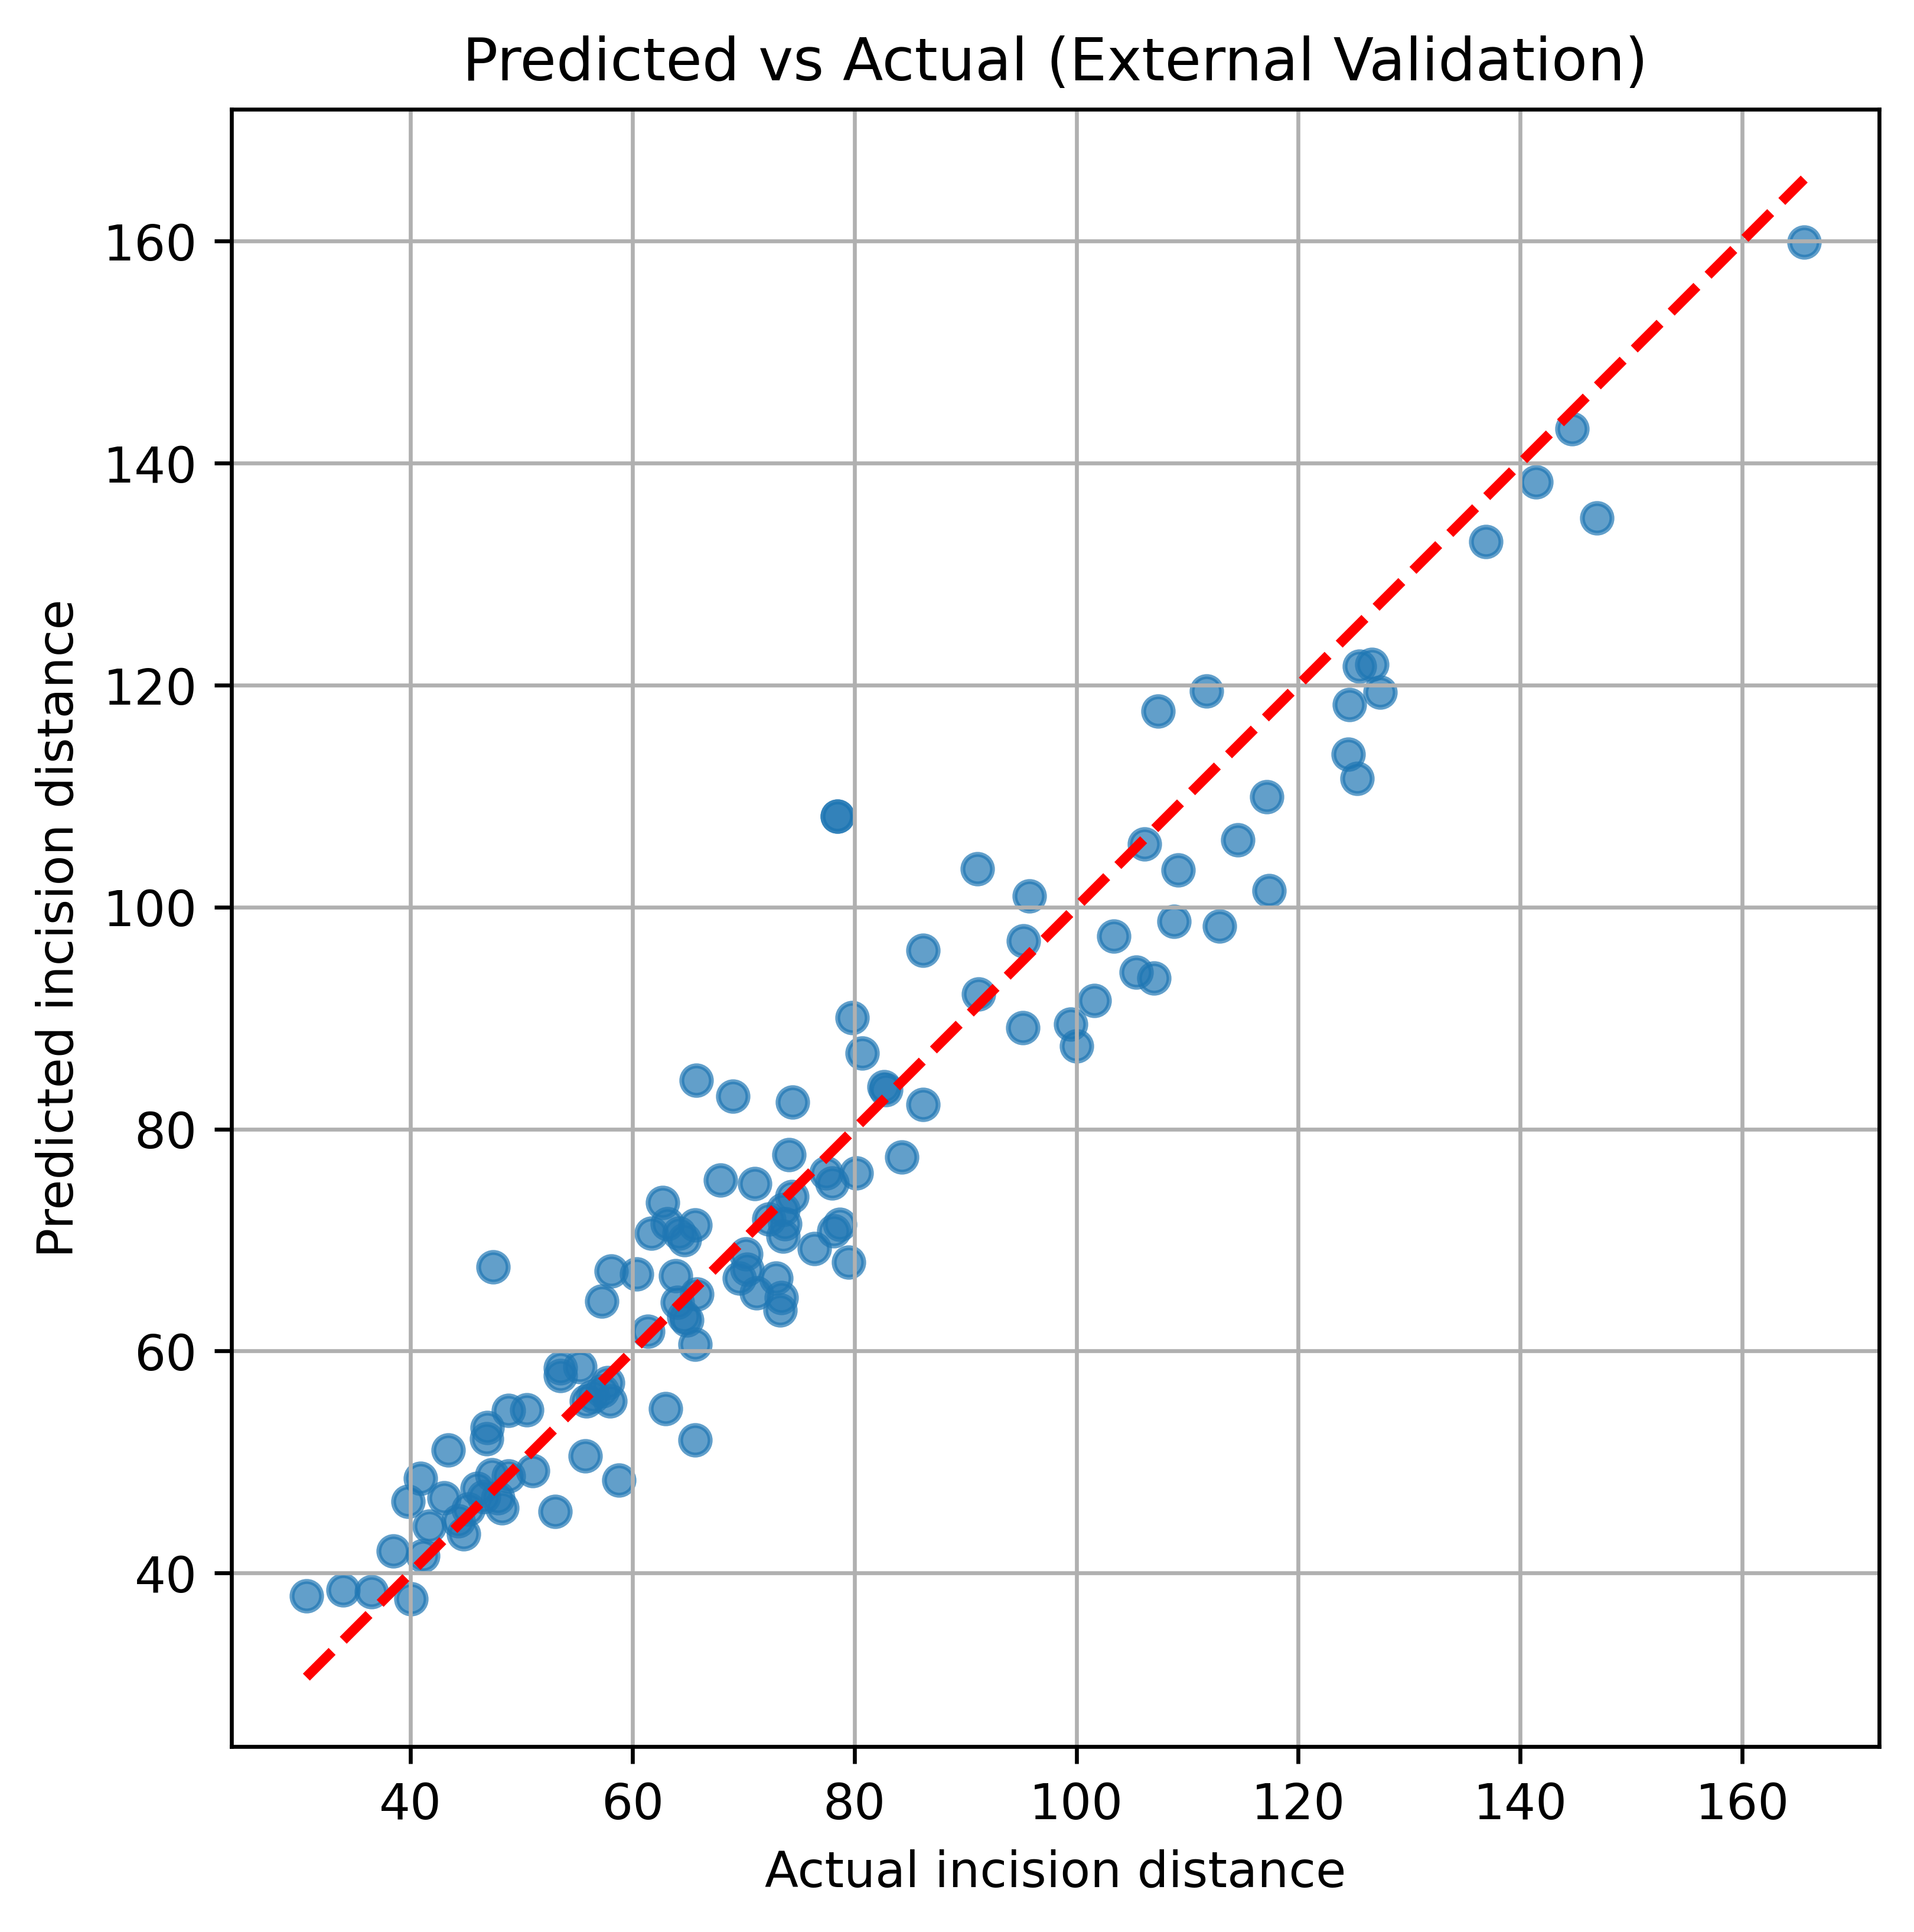

In [ ]:
# ============================
# Predicted vs Actual (external validation)
# ============================

import matplotlib.pyplot as plt
import numpy as np

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.figure(figsize=(6,6), dpi=600)

plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual incision distance")
plt.ylabel("Predicted incision distance")
plt.title("Predicted vs Actual (External Validation)")
plt.axis("equal")
plt.grid(True)

plt.savefig("pred_vs_actual_external_600dpi.png", dpi=600, bbox_inches="tight")
plt.savefig("pred_vs_actual_external_600dpi.tiff", dpi=600, bbox_inches="tight")

plt.show()

# **Calibration plot**

/tmp/ipykernel_434/2355591984.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration = df_cal.groupby("bin").mean()


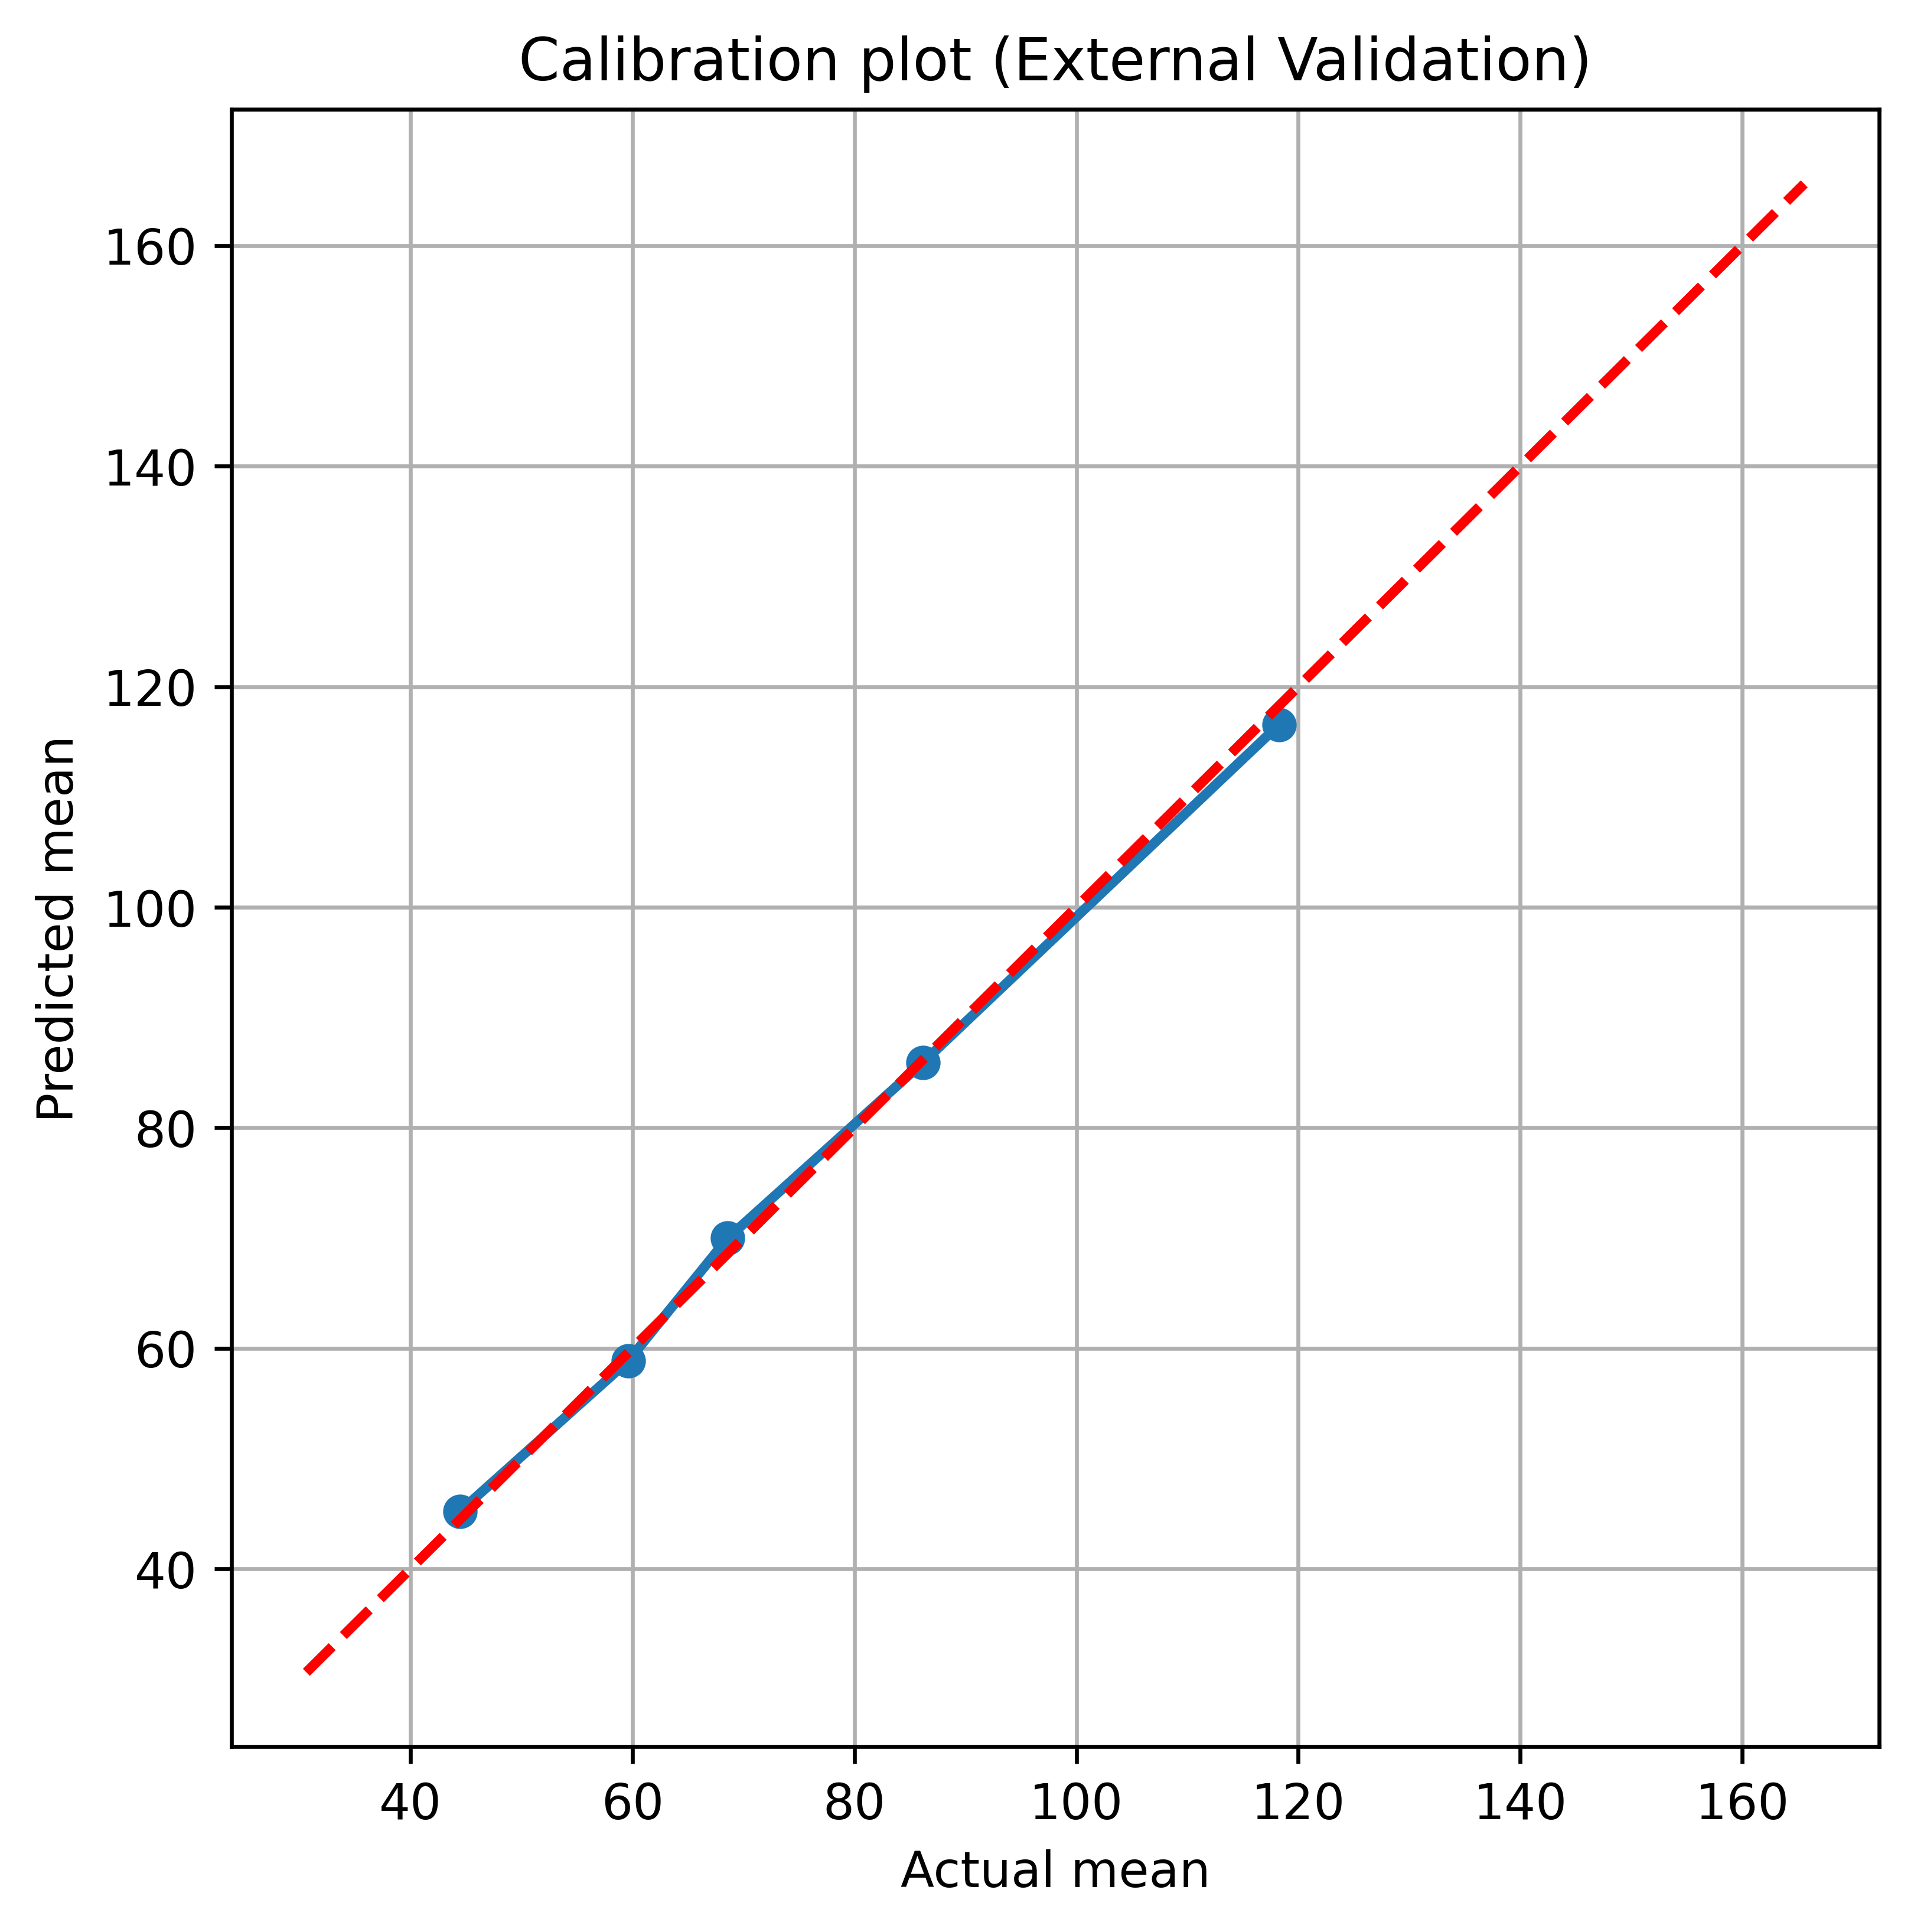

In [ ]:
# ============================
# Calibration plot
# ============================

# ============================
# Calibration plot (high resolution)
# ============================

import pandas as pd
import matplotlib.pyplot as plt

df_cal = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

df_cal["bin"] = pd.qcut(df_cal["pred"], 5, duplicates="drop")
calibration = df_cal.groupby("bin").mean()

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.figure(figsize=(6,6), dpi=600)

plt.plot(calibration["true"], calibration["pred"], "o-", linewidth=2)
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.xlabel("Actual mean")
plt.ylabel("Predicted mean")
plt.title("Calibration plot (External Validation)")
plt.grid(True)

plt.savefig("calibration_external_600dpi.png", dpi=600, bbox_inches="tight")
plt.savefig("calibration_external_600dpi.tiff", dpi=600, bbox_inches="tight")

plt.show()

# **Bland–Altman plot**

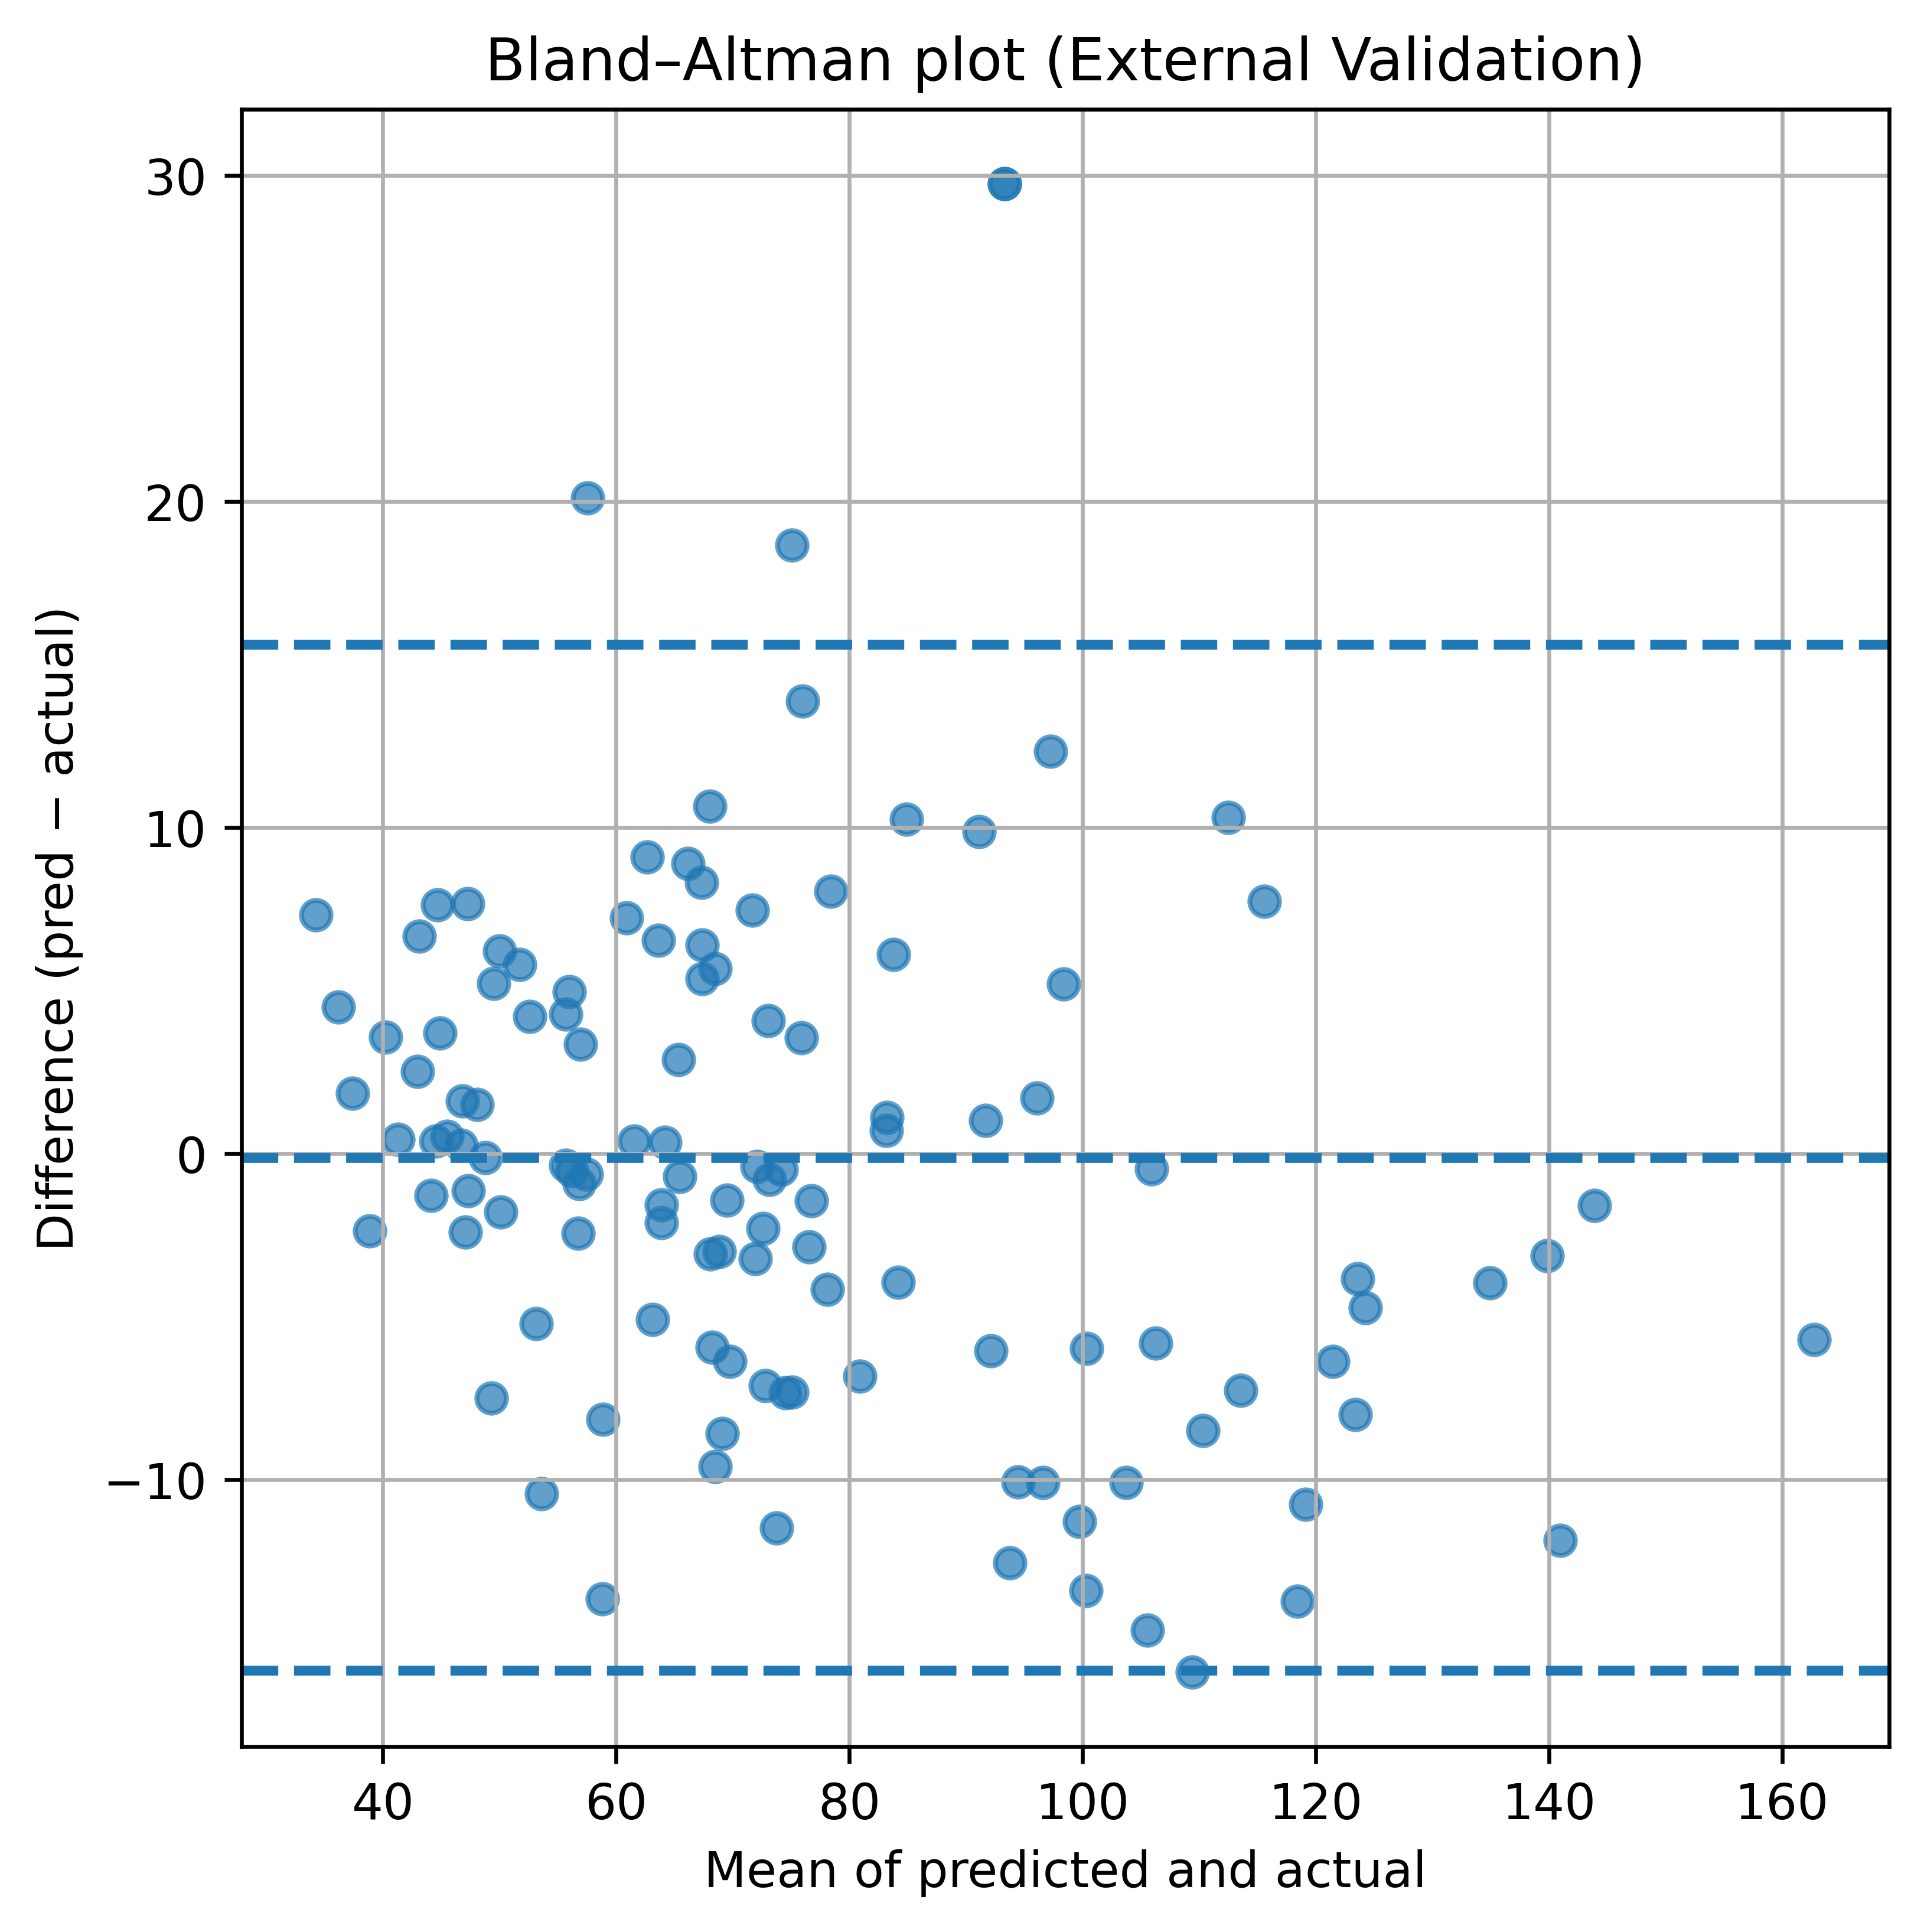

Mean diff: -0.11866514160970017
Upper LoA: 15.610100247547331
Lower LoA: -15.847430530766731


In [ ]:
# ============================
# Bland–Altman plot
# ============================


import numpy as np
import matplotlib.pyplot as plt

mean_vals = (y_true + y_pred) / 2
diff_vals = y_pred - y_true

mean_diff = np.mean(diff_vals)
std_diff = np.std(diff_vals)

upper = mean_diff + 1.96 * std_diff
lower = mean_diff - 1.96 * std_diff

plt.figure(figsize=(6,6), dpi=600)

plt.scatter(mean_vals, diff_vals, alpha=0.7)
plt.axhline(mean_diff, linestyle="--", linewidth=2)
plt.axhline(upper, linestyle="--", linewidth=2)
plt.axhline(lower, linestyle="--", linewidth=2)

plt.xlabel("Mean of predicted and actual")
plt.ylabel("Difference (pred − actual)")
plt.title("Bland–Altman plot (External Validation)")
plt.grid(True)

plt.savefig("bland_altman_external_600dpi.png", dpi=600, bbox_inches="tight")
plt.savefig("bland_altman_external_600dpi.tiff", dpi=600, bbox_inches="tight")

plt.show()

print("Mean diff:", mean_diff)
print("Upper LoA:", upper)
print("Lower LoA:", lower)

# **Predicted Area 2026 Revised Version**

Correlation with Disc_Area (raw features only):
Disc_Area      1.000000
Kambin_Base    0.875532
Disc_Width     0.862648
Disc_AP        0.731931
Cord_Width     0.121119
Depth         -0.030158
Name: Disc_Area, dtype: float64

Correlation between Disc_AP and Disc_Width: 0.799400


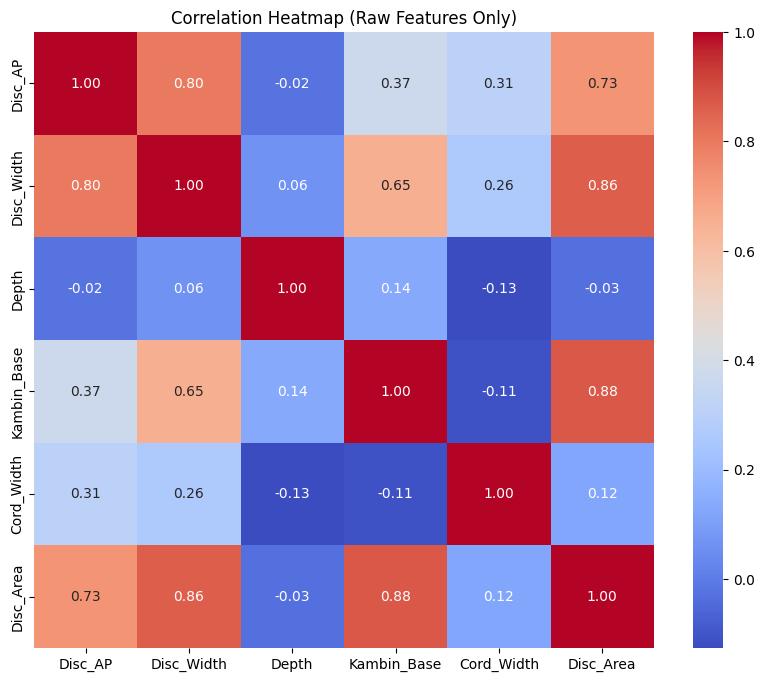

In [ ]:
# ============================
# Part 1: Exploratory analysis for Disc_Area
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 原始數值特徵
raw_numeric_features = [
    'Disc_AP',
    'Disc_Width',
    'Depth',
    'Kambin_Base',
    'Cord_Width'
]

target_column = 'Disc_Area'
level_feature_columns = list(level_columns)

# 1. Correlation between raw features and Disc_Area (exploratory)
correlation = df_train[raw_numeric_features + [target_column]].corr()[target_column].sort_values(ascending=False)
print("Correlation with Disc_Area (raw features only):")
print(correlation)

# 2. Correlation between Disc_AP and Disc_Width
correlation_disc_ap_width = df_train[['Disc_AP', 'Disc_Width']].corr().iloc[0, 1]
print(f"\nCorrelation between Disc_AP and Disc_Width: {correlation_disc_ap_width:.6f}")

# 3. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[raw_numeric_features + [target_column]].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Raw Features Only)')
plt.show()

=== Internal Split Check ===
Internal training images: 480
Internal validation images: 125
Internal training patients: 96
Internal validation patients: 25
Overlapping MRNs between internal train and val: 0

=== External Test Check ===
External test images: 120
External test patients: 40
Overlapping MRNs between development set and external test: 0

=== PCA Info ===
Number of components selected: 4
Explained variance ratio: [0.44929901 0.26319353 0.16823216 0.09487376]
Total explained variance: 0.9755984689638545

Selected features for ANN: ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== Final Model Input Shapes ===
X_internal_train: (480, 9)
X_internal_val: (125, 9)
X_external_test: (120, 9)

=== Training run 1/10 (seed=0) ===
Run seed=0: val R²=0.9724, val MAE=34.9513

=== Training run 2/10 (seed=1) ===
Run seed=1: val R²=0.9765, val MAE=31.7753

=== Training run 3/10 (seed=2) ===
Run seed=2: val R²=0.9796, val MAE=29.9271

=== T

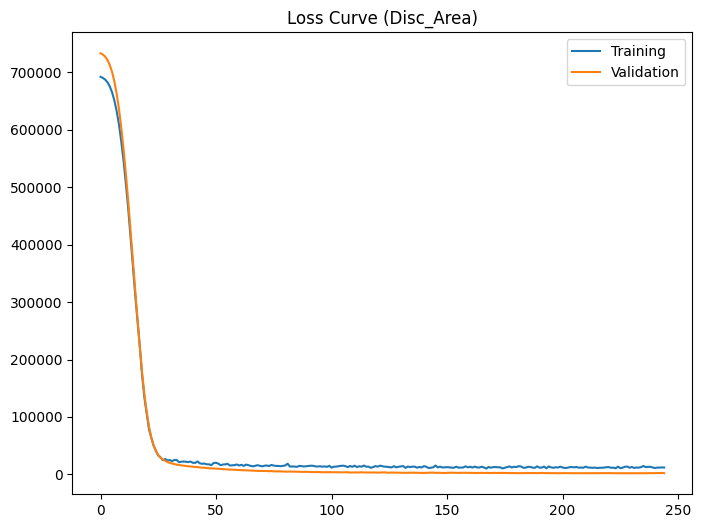

In [ ]:
# ============================
# Part 2: Patient-level internal validation + external test for Disc_Area
# ============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, skew
import random
import os
import pickle


# ----------------------------
# Step 1: Data preparation
# ----------------------------
target_column = 'Disc_Area'
raw_numeric_features = ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']
level_feature_columns = list(level_columns)

groups = df_train['MRN'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df_train, groups=groups))

df_internal_train = df_train.iloc[train_idx].copy()
df_internal_val = df_train.iloc[val_idx].copy()

print("=== Internal Split Check ===")
print(f"Internal training images: {len(df_internal_train)}")
print(f"Internal validation images: {len(df_internal_val)}")
print(f"Internal training patients: {df_internal_train['MRN'].nunique()}")
print(f"Internal validation patients: {df_internal_val['MRN'].nunique()}")

overlap_internal = set(df_internal_train['MRN']).intersection(set(df_internal_val['MRN']))
print(f"Overlapping MRNs between internal train and val: {len(overlap_internal)}")

print("\n=== External Test Check ===")
print(f"External test images: {len(df_test)}")
print(f"External test patients: {df_test['MRN'].nunique()}")

overlap_external = set(df_train['MRN']).intersection(set(df_test['MRN']))
print(f"Overlapping MRNs between development set and external test: {len(overlap_external)}")


# ----------------------------
# Step 2: PCA
# ----------------------------
scaler_pca = StandardScaler()

X_internal_train_raw = scaler_pca.fit_transform(df_internal_train[raw_numeric_features])
X_internal_val_raw = scaler_pca.transform(df_internal_val[raw_numeric_features])
X_external_test_raw = scaler_pca.transform(df_test[raw_numeric_features])

pca = PCA(n_components=0.90)

X_internal_train_pca = pca.fit_transform(X_internal_train_raw)
X_internal_val_pca = pca.transform(X_internal_val_raw)
X_external_test_pca = pca.transform(X_external_test_raw)

print("\n=== PCA Info ===")
print("Number of components selected:", pca.n_components_)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca.explained_variance_ratio_))

pca_features = [f'PCA{i+1}' for i in range(pca.n_components_)]

df_internal_train_pca = pd.DataFrame(X_internal_train_pca, columns=pca_features, index=df_internal_train.index)
df_internal_val_pca = pd.DataFrame(X_internal_val_pca, columns=pca_features, index=df_internal_val.index)
df_external_test_pca = pd.DataFrame(X_external_test_pca, columns=pca_features, index=df_test.index)

X_internal_train_df = pd.concat([df_internal_train_pca, df_internal_train[level_feature_columns]], axis=1)
X_internal_val_df = pd.concat([df_internal_val_pca, df_internal_val[level_feature_columns]], axis=1)
X_external_test_df = pd.concat([df_external_test_pca, df_test[level_feature_columns]], axis=1)

selected_features = list(X_internal_train_df.columns)

print("\nSelected features for ANN:", selected_features)

y_internal_train = df_internal_train[target_column].values
y_internal_val = df_internal_val[target_column].values
y_external_test = df_test[target_column].values


# ----------------------------
# Step 3: ANN scaler
# ----------------------------
scaler_ann = StandardScaler()

X_internal_train = scaler_ann.fit_transform(X_internal_train_df)
X_internal_val = scaler_ann.transform(X_internal_val_df)
X_external_test = scaler_ann.transform(X_external_test_df)

print("\n=== Final Model Input Shapes ===")
print("X_internal_train:", X_internal_train.shape)
print("X_internal_val:", X_internal_val.shape)
print("X_external_test:", X_external_test.shape)


# ----------------------------
# Step 4: ANN
# ----------------------------
def set_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def build_disc_area_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
        Dropout(0.1),
        Dense(16, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='mean_squared_error',
        metrics=['mean_squared_error']
    )

    return model


# Run multiple times and select the model with the best internal validation R²
n_runs = 10
best_val_r2 = -np.inf
best_seed = None
best_weights = None
best_history_dict = None

for seed in range(n_runs):
    print(f"\n=== Training run {seed+1}/{n_runs} (seed={seed}) ===")

    tf.keras.backend.clear_session()
    set_all_seeds(seed)

    current_model = build_disc_area_model(X_internal_train.shape[1])

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )

    current_history = current_model.fit(
        X_internal_train,
        y_internal_train,
        validation_data=(X_internal_val, y_internal_val),
        epochs=500,
        batch_size=8,
        callbacks=[early_stopping],
        verbose=0
    )

    current_val_pred = current_model.predict(X_internal_val, verbose=0).flatten()
    current_val_r2 = r2_score(y_internal_val, current_val_pred)
    current_val_mae = mean_absolute_error(y_internal_val, current_val_pred)

    print(f"Run seed={seed}: val R²={current_val_r2:.4f}, val MAE={current_val_mae:.4f}")

    if current_val_r2 > best_val_r2:
        best_val_r2 = current_val_r2
        best_seed = seed
        best_weights = current_model.get_weights()
        best_history_dict = current_history.history

print("\n=== Best model selected ===")
print(f"Best seed: {best_seed}")
print(f"Best internal val R²: {best_val_r2:.4f}")

disc_area_model = build_disc_area_model(X_internal_train.shape[1])
disc_area_model.set_weights(best_weights)

class SimpleHistory:
    pass

history = SimpleHistory()
history.history = best_history_dict


# ----------------------------
# Step 5: Internal validation
# ----------------------------
y_val_pred = disc_area_model.predict(X_internal_val, verbose=0).flatten()

val_mse = mean_squared_error(y_internal_val, y_val_pred)
val_mae = mean_absolute_error(y_internal_val, y_val_pred)
val_r2 = r2_score(y_internal_val, y_val_pred)

print("\n=== Internal Validation Performance ===")
print(f"MSE: {val_mse:.4f}")
print(f"MAE: {val_mae:.4f}")
print(f"R² : {val_r2:.4f}")


# ----------------------------
# Step 6: External validation
# ----------------------------
y_test_pred = disc_area_model.predict(X_external_test, verbose=0).flatten()

test_mse = mean_squared_error(y_external_test, y_test_pred)
test_mae = mean_absolute_error(y_external_test, y_test_pred)
test_r2 = r2_score(y_external_test, y_test_pred)

print("\n=== External Validation Performance ===")
print(f"MSE: {test_mse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R² : {test_r2:.4f}")


# ----------------------------
# Step 7: Bootstrap CI
# ----------------------------
n_boot = 1000
rng = np.random.default_rng(42)

mse_list = []
mae_list = []
r2_list = []

for _ in range(n_boot):
    idx = rng.integers(0, len(y_external_test), len(y_external_test))

    y_true_b = y_external_test[idx]
    y_pred_b = y_test_pred[idx]

    mse_list.append(mean_squared_error(y_true_b, y_pred_b))
    mae_list.append(mean_absolute_error(y_true_b, y_pred_b))
    r2_list.append(r2_score(y_true_b, y_pred_b))

def ci95(x):
    return np.percentile(x, [2.5, 97.5])

print("\n=== External Validation 95% CI (bootstrap) ===")
print("MSE:", ci95(mse_list))
print("MAE:", ci95(mae_list))
print("R2 :", ci95(r2_list))


# ----------------------------
# Step 8: feature importance
# ----------------------------
weights = disc_area_model.get_weights()[0]

importance = np.abs(weights).mean(axis=1)

importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importance ===")
print(importance_df)


# ----------------------------
# Step 9: noise test
# ----------------------------
X_test_noisy = X_external_test + np.random.normal(0, 0.1, X_external_test.shape)

y_test_pred_noisy = disc_area_model.predict(X_test_noisy, verbose=0).flatten()

print("\n=== Noisy External Test ===")
print(mean_squared_error(y_external_test, y_test_pred_noisy))
print(mean_absolute_error(y_external_test, y_test_pred_noisy))
print(r2_score(y_external_test, y_test_pred_noisy))


# ----------------------------
# Step 10: Loss curve
# ----------------------------
plt.figure(figsize=(8, 6))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.legend()
plt.title('Loss Curve (Disc_Area)')
plt.show()

# **Save the Predict AREA Model**

In [ ]:
# ============================
# Step 11: Save best disc_area model and preprocessing bundle
# ============================

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

save_dir = '/content/drive/My Drive/saved_models_2026/disc_area_model/'
os.makedirs(save_dir, exist_ok=True)

required_objects = {
    "model": disc_area_model,
    "encoder": encoder,
    "scaler_pca": scaler_pca,
    "pca": pca,
    "scaler_ann": scaler_ann,
    "raw_numeric_features": raw_numeric_features,
    "level_feature_columns": level_feature_columns,
    "selected_features": selected_features,
    "target_column": target_column
}

for name, obj in required_objects.items():
    if obj is None:
        raise ValueError(f"Object {name} has not been properly initialized")

disc_area_model.save(os.path.join(save_dir, 'disc_area_model.keras'))
print("Model successfully saved:", os.path.join(save_dir, 'disc_area_model.keras'))

preprocessing_bundle = {
    "encoder": encoder,
    "scaler_pca": scaler_pca,
    "pca": pca,
    "scaler_ann": scaler_ann,
    "raw_numeric_features": raw_numeric_features,
    "level_feature_columns": level_feature_columns,
    "selected_features": selected_features,
    "target_column": target_column,
    "best_seed": best_seed,
    "best_val_r2": best_val_r2
}

with open(os.path.join(save_dir, 'preprocessing_bundle.pkl'), 'wb') as f:
    pickle.dump(preprocessing_bundle, f)

print("Preprocessing bundle successfully saved:", os.path.join(save_dir, 'preprocessing_bundle.pkl'))

for file_name in ['disc_area_model.keras', 'preprocessing_bundle.pkl']:
    file_path = os.path.join(save_dir, file_name)
    if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
        print(f"檔案 {file_name} exists and is not empty, size: {os.path.getsize(file_path)} bytes")
    else:
        raise ValueError(f"File {file_name} failed to save or is empty")

print("Disc_Area model and preprocessing bundle have been successfully saved to:", save_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
模型儲存成功: /content/drive/My Drive/saved_models_2026/disc_area_model/disc_area_model.keras
Preprocessing bundle 儲存成功: /content/drive/My Drive/saved_models_2026/disc_area_model/preprocessing_bundle.pkl
檔案 disc_area_model.keras 存在且非空白，大小: 29654 bytes
檔案 preprocessing_bundle.pkl 存在且非空白，大小: 2770 bytes
Disc_Area 模型與 preprocessing bundle 已成功儲存至: /content/drive/My Drive/saved_models_2026/disc_area_model/


# **Load Disc Area Model**

In [ ]:
import pickle
import os

save_dir = '/content/drive/My Drive/saved_models_2026/disc_area_model/'

with open(os.path.join(save_dir, 'preprocessing_bundle.pkl'), 'rb') as f:
    loaded_bundle = pickle.load(f)

print("best_seed:", loaded_bundle.get("best_seed"))
print("best_val_r2:", loaded_bundle.get("best_val_r2"))

best_seed: 2
best_val_r2: 0.9795571155059404


# **Validation**

In [ ]:
import os
import pickle
import pandas as pd
import numpy as np
import tensorflow as tf
from google.colab import drive

# ============================
# Step A: Mount Drive
# ============================
drive.mount('/content/drive', force_remount=False)

# ============================
# Step B: Load saved disc_area model and bundle
# ============================
save_dir_area = '/content/drive/My Drive/saved_models_2026/disc_area_model/'

with open(os.path.join(save_dir_area, 'preprocessing_bundle.pkl'), 'rb') as f:
    area_bundle = pickle.load(f)

area_model = tf.keras.models.load_model(
    os.path.join(save_dir_area, 'disc_area_model.keras')
)

area_encoder = area_bundle["encoder"]
area_scaler_pca = area_bundle["scaler_pca"]
area_pca = area_bundle["pca"]
area_scaler_ann = area_bundle["scaler_ann"]
area_raw_numeric_features = area_bundle["raw_numeric_features"]
area_level_feature_columns = area_bundle["level_feature_columns"]
area_selected_features = area_bundle["selected_features"]

print("=== DISC_AREA BUNDLE CHECK ===")
print("raw_numeric_features:", area_raw_numeric_features)
print("level_feature_columns:", area_level_feature_columns)
print("selected_features:", area_selected_features)
print("PCA n_components:", getattr(area_pca, "n_components_", None))
print("best_seed:", area_bundle.get("best_seed"))
print("best_val_r2:", area_bundle.get("best_val_r2"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== DISC_AREA BUNDLE CHECK ===
raw_numeric_features: ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']
level_feature_columns: ['Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']
selected_features: ['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']
PCA n_components: 4
best_seed: 2
best_val_r2: 0.9795571155059404


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
def debug_app_pipeline_in_colab(
    level,
    disc_ap,
    disc_width,
    cord_width,
    kambin_base,
    depth,
    model,
    encoder,
    scaler_pca,
    pca,
    scaler_ann,
    raw_numeric_features,
    level_feature_columns,
    selected_features,
    model_name="DISC_AREA",
):
    # Keep consistent with the HF app
    cord_width = cord_width / 2

    input_df = pd.DataFrame(
        [{
            "Disc_AP": disc_ap,
            "Disc_Width": disc_width,
            "Depth": depth,
            "Kambin_Base": kambin_base,
            "Cord_Width": cord_width,
            "Level": level,
        }],
        index=[0]
    )

    print(f"\n================ DEBUG START ({model_name}) ================")

    print("\n=== input_df ===")
    print(input_df)

    X_raw = input_df[raw_numeric_features]
    print("\n=== X_raw ===")
    print(X_raw)
    print("X_raw columns:", list(X_raw.columns))

    X_raw_scaled = scaler_pca.transform(X_raw)
    print("\n=== X_raw_scaled ===")
    print(X_raw_scaled)

    X_pca = pca.transform(X_raw_scaled)
    pca_features = [f"PCA{i+1}" for i in range(X_pca.shape[1])]
    df_pca = pd.DataFrame(X_pca, columns=pca_features, index=[0])

    print("\n=== df_pca ===")
    print(df_pca)
    print("df_pca columns:", list(df_pca.columns))

    level_encoded = encoder.transform(input_df[["Level"]])
    if hasattr(level_encoded, "toarray"):
        level_encoded = level_encoded.toarray()

    df_level = pd.DataFrame(level_encoded, columns=level_feature_columns, index=[0])

    print("\n=== df_level ===")
    print(df_level)
    print("df_level columns:", list(df_level.columns))

    X_final_df = pd.concat([df_pca, df_level], axis=1)

    for col in selected_features:
        if col not in X_final_df.columns:
            X_final_df[col] = 0

    X_final_df = X_final_df[selected_features]

    print("\n=== selected_features ===")
    print(selected_features)

    print("\n=== X_final_df ===")
    print(X_final_df)
    print("X_final_df columns:", list(X_final_df.columns))

    X_final = scaler_ann.transform(X_final_df)

    print("\n=== X_final ===")
    print(X_final)
    print("X_final shape:", X_final.shape)

    pred = model.predict(X_final, verbose=0).flatten()[0]

    print("\n=== prediction ===")
    print(pred)

    print(f"================ DEBUG END ({model_name}) =================\n")

    return {
        "input_df": input_df,
        "X_raw": X_raw,
        "X_raw_scaled": X_raw_scaled,
        "X_pca": X_pca,
        "df_pca": df_pca,
        "df_level": df_level,
        "X_final_df": X_final_df,
        "X_final": X_final,
        "prediction": pred,
    }

In [ ]:
result_area = debug_app_pipeline_in_colab(
    level="L34",
    disc_ap=47.096377,
    disc_width=61.800006,
    cord_width=23.15607,   # Note: Enter the original value here; it will be divided by 2 inside the function.
    kambin_base=10.204207,
    depth=56.6,
    model=area_model,
    encoder=area_encoder,
    scaler_pca=area_scaler_pca,
    pca=area_pca,
    scaler_ann=area_scaler_ann,
    raw_numeric_features=area_raw_numeric_features,
    level_feature_columns=area_level_feature_columns,
    selected_features=area_selected_features,
    model_name="DISC_AREA",
)


================ DEBUG START (DISC_AREA) ================

=== input_df ===
     Disc_AP  Disc_Width  Depth  Kambin_Base  Cord_Width Level
0  47.096377   61.800006   56.6    10.204207   11.578035   L34

=== X_raw ===
     Disc_AP  Disc_Width  Depth  Kambin_Base  Cord_Width
0  47.096377   61.800006   56.6    10.204207   11.578035
X_raw columns: ['Disc_AP', 'Disc_Width', 'Depth', 'Kambin_Base', 'Cord_Width']

=== X_raw_scaled ===
[[ 1.65926793  1.20034318 -0.82812353 -0.68437969  0.52693691]]

=== df_pca ===
       PCA1      PCA2      PCA3      PCA4
0  1.444951  1.457711 -0.217718 -1.134859
df_pca columns: ['PCA1', 'PCA2', 'PCA3', 'PCA4']

=== df_level ===
   Level_L12  Level_L23  Level_L34  Level_L45  Level_L5S1
0        0.0        0.0        1.0        0.0         0.0
df_level columns: ['Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== selected_features ===
['PCA1', 'PCA2', 'PCA3', 'PCA4', 'Level_L12', 'Level_L23', 'Level_L34', 'Level_L45', 'Level_L5S1']

=== X_fi